# Finite-Horizon Sample-Path Bounds for Approximate Dynamic Programming

This notebook implements the **finite-horizon** version of the sample-path dependent AIS bound (Corollary 1). The discount factor $\gamma$ is absorbed into time-varying costs $c_t(s,a) = \gamma^{t-1} c(s,a)$, yielding a standard finite-horizon undiscounted MDP. The backward $\alpha$-$\beta$ recursion is run directly from $t = T$ to $t = 1$ as stated in the theorem, eliminating the gap between theory and numerics.

With $T = 100$ and $\gamma = 0.75$, the truncation error is $\gamma^{100} \approx 3 \times 10^{-13}$, so the finite-horizon values at $t=1$ match their infinite-horizon counterparts to numerical precision.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
from matplotlib import pyplot as plt

from models import InventoryMDP
from solvers import value_iteration, policy_evaluation
from bounds import (weight_function, compute_kappa,
                    weighted_norm_bound_alpha_beta, sample_path_bound,
                    sample_path_bound_restricted)

T = 100
print(f'Horizon T = {T},  gamma^T = {0.75**T:.2e}')

Horizon T = 100,  gamma^T = 3.21e-13


## 1. Model Definition

| Parameter | True model $M$ | Approximate model $\hat M$ |
|---|---|---|
| $S_{\max}$ | 500 | 500 |
| $\gamma$ | 0.75 | 0.75 |
| Demand $\sim \text{Bin}(n,q)$ | $n=10,\; q=0.4$ | $n=10,\; q=0.5$ |
| Holding cost $c_h$ | 4 | 3.8 |
| Shortage cost $c_s$ | 2 | 2 |
| Ordering cost $p$ | 5 | 5 |

In [2]:
M     = InventoryMDP(s_max=500, gamma=0.75, n=10, q=0.4, ch=4, cs=2, p=5)
M_hat = InventoryMDP(s_max=500, gamma=0.75, n=10, q=0.5, ch=3.8, cs=2, p=5)

s_max = M.s_max
gamma = M.gamma
states = M.states
num_states = M.num_states
print(f'State space size:  {num_states}')
print(f'Action space size: {M.num_actions}')

State space size:  1001
Action space size: 501


## 2. Infinite-Horizon Solutions (for comparison)

Solve both models via value iteration, evaluate $\hat\pi^\star$ on $M$, and compute the existing bounds.

In [3]:
print('Value iteration on M (tight threshold) ...')
V_star_ih, pi_star_ih = value_iteration(M, thres=1e-12)

print('Value iteration on M_hat (tight threshold) ...')
V_hat_star_ih, pi_hat_star_ih = value_iteration(M_hat, thres=1e-12)

sigma_star = int(states[np.where(pi_star_ih == 0)[0][0]])
sigma_hat  = int(states[np.where(pi_hat_star_ih == 0)[0][0]])
print(f'sigma* = {sigma_star},  sigma_hat* = {sigma_hat}')

print('Policy evaluation: pi_hat* on M (tight threshold) ...')
V_pi_hat_ih = policy_evaluation(M, pi_hat_star_ih, thres=1e-12)
gap_ih = V_pi_hat_ih - V_star_ih
print(f'Max gap = {np.max(gap_ih):.4f}')

# Sup-norm bound
w_sup = weight_function(M_hat, 0)
kappa_sup = max(
    compute_kappa(M, w_sup, pi_star_ih),
    compute_kappa(M, w_sup, pi_hat_star_ih),
    compute_kappa(M_hat, w_sup, pi_hat_star_ih),
)
bound_sup = weighted_norm_bound_alpha_beta(
    V_hat_star_ih, pi_hat_star_ih, w_sup, M, M_hat, kappa_sup)
sup_bound_curve = bound_sup * w_sup
print(f'Sup-norm bound = {bound_sup:.4f}')

# Weighted-norm bound
ell_w = 1.5e-2
w_w = weight_function(M_hat, ell_w)
kappa_w = max(
    compute_kappa(M, w_w, pi_star_ih),
    compute_kappa(M, w_w, pi_hat_star_ih),
    compute_kappa(M_hat, w_w, pi_hat_star_ih),
)
bound_w = weighted_norm_bound_alpha_beta(
    V_hat_star_ih, pi_hat_star_ih, w_w, M, M_hat, kappa_w)
weighted_bound_curve = bound_w * w_w
print(f'Weighted-norm scalar = {bound_w:.4f}')

# Infinite-horizon sample-path bounds
alpha_max_ih, alpha_sup_ih, history_ih = sample_path_bound(
    M, M_hat, V_hat_star_ih, pi_star_ih, pi_hat_star_ih)
alpha_res_ih, _ = sample_path_bound_restricted(
    M, M_hat, V_hat_star_ih, pi_hat_star_ih)
print(f'IH max 2*alpha_max = {2*np.max(alpha_max_ih):.4f}')
print(f'IH max 2*alpha_res = {2*np.max(alpha_res_ih):.4f}')
print(f'IH max 2*alpha_sup = {2*np.max(alpha_sup_ih):.4f}')

Value iteration on M (tight threshold) ...


Value iteration on M_hat (tight threshold) ...


sigma* = 2,  sigma_hat* = 3
Policy evaluation: pi_hat* on M (tight threshold) ...


Max gap = 2.0112


Sup-norm bound = 891.2000


Weighted-norm scalar = 53.1585


IH max 2*alpha_max = 902.4000
IH max 2*alpha_res = 902.4000
IH max 2*alpha_sup = 917.3762


## 3. Finite-Horizon Backward Induction

The discount factor is absorbed into the per-step cost:
$$c_t(s,a) = \gamma^{t-1}[p \cdot a + h(s)]$$

Backward induction proceeds from $t = T$ to $t = 1$ with $V_{T+1}(s) = 0$:
$$V_t(s) = \min_a \left[ c_t(s,a) + \sum_{s'} V_{t+1}(s') P(s'|s,a) \right]$$

There is **no** $\gamma$ in front of the continuation value since discounting is in $c_t$.

In [4]:
def finite_horizon_backward_induction(model, T):
    """Solve finite-horizon MDP with time-varying costs c_t = gamma^{t-1} * c.
    
    Returns:
        V_all: shape (T+2, num_states) -- V_all[t] is V_t(s), V_all[T+1] = 0
        pi_all: shape (T+1, num_states) -- pi_all[t] is pi_t(s) for t=1..T
    """
    sm = model.s_max
    gam = model.gamma
    W = model.W
    p = model.p
    n_demand = len(W)
    ns = model.num_states   # 2*sm + 1
    H_len = 3 * sm + 1
    
    # Precompute h(s) for all states
    h_vec = model.h_vec(model.states)  # shape (ns,)
    
    V_all = np.zeros((T + 2, ns))
    pi_all = np.zeros((T + 1, ns), dtype=int)
    # V_all[T+1, :] = 0 (terminal)
    
    H = np.zeros(H_len)
    
    for t in range(T, 0, -1):
        gamma_t = gam ** (t - 1)  # gamma^{t-1}
        
        # Build H-array for V_{t+1}
        V_next = V_all[t + 1]
        for z in range(-sm, 2 * sm + 1):
            H[z + sm] = 0.0
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                H[z + sm] += W[w] * V_next[ns_idx + sm]
        
        # Bellman update for each state
        for si in range(ns):
            s_int = si - sm  # actual state value
            h_s = h_vec[si]
            
            # a=0
            best_a = 0
            best_val = gamma_t * h_s + H[s_int + sm]
            
            for a in range(1, sm + 1):
                z_idx = min(s_int + a, 2 * sm) + sm
                val = gamma_t * (p * a + h_s) + H[z_idx]
                if val < best_val:
                    best_val = val
                    best_a = a
            
            V_all[t, si] = best_val
            pi_all[t, si] = best_a
    
    return V_all, pi_all

print('Running backward induction ...')

Running backward induction ...


In [5]:
print('Backward induction on M ...')
V_M_all, pi_M_all = finite_horizon_backward_induction(M, T)

print('Backward induction on M_hat ...')
V_Mhat_all, pi_Mhat_all = finite_horizon_backward_induction(M_hat, T)

# Check base-stock levels at t=1
sigma_fh = int(states[np.where(pi_M_all[1] == 0)[0][0]])
sigma_hat_fh = int(states[np.where(pi_Mhat_all[1] == 0)[0][0]])
print(f'FH base-stock at t=1: sigma* = {sigma_fh}, sigma_hat* = {sigma_hat_fh}')

Backward induction on M ...


Backward induction on M_hat ...


FH base-stock at t=1: sigma* = 2, sigma_hat* = 3


### Truncation Validation

Verify $|V^\star_{\text{FH},1}(s) - V^\star_{\infty}(s)| < 10^{-10}$ for both models.

In [6]:
trunc_M = np.max(np.abs(V_M_all[1] - V_star_ih))
trunc_Mhat = np.max(np.abs(V_Mhat_all[1] - V_hat_star_ih))
print(f'Truncation error (M):     {trunc_M:.2e}')
print(f'Truncation error (M_hat): {trunc_Mhat:.2e}')
assert trunc_M < 1e-9, f'Truncation error too large: {trunc_M}'
assert trunc_Mhat < 1e-9, f'Truncation error too large: {trunc_Mhat}'
print('PASS: V_fh[1] matches V_inf to < 1e-9')

Truncation error (M):     4.50e-10
Truncation error (M_hat): 9.09e-11
PASS: V_fh[1] matches V_inf to < 1e-9


## 4. Finite-Horizon Policy Evaluation

Evaluate $\hat\pi^\star_t$ under the true model $M$:
$$V^{\hat\pi^\star}_t(s) = c_t(s, \hat\pi^\star_t(s)) + \sum_{s'} V^{\hat\pi^\star}_{t+1}(s') P_M(s'|s, \hat\pi^\star_t(s))$$

In [7]:
def finite_horizon_policy_eval(model, pi_all, T):
    """Evaluate time-varying policy pi_all under model's dynamics and costs.
    
    Args:
        model: InventoryMDP (true model for dynamics and costs)
        pi_all: shape (T+1, num_states), policy at each time step
        T: horizon
    
    Returns:
        V_all: shape (T+2, num_states)
    """
    sm = model.s_max
    gam = model.gamma
    W = model.W
    p = model.p
    n_demand = len(W)
    ns = model.num_states
    H_len = 3 * sm + 1
    
    h_vec = model.h_vec(model.states)
    
    V_all = np.zeros((T + 2, ns))
    H = np.zeros(H_len)
    
    for t in range(T, 0, -1):
        gamma_t = gam ** (t - 1)
        
        # Build H-array for V_{t+1}
        V_next = V_all[t + 1]
        for z in range(-sm, 2 * sm + 1):
            H[z + sm] = 0.0
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                H[z + sm] += W[w] * V_next[ns_idx + sm]
        
        for si in range(ns):
            s_int = si - sm
            a = pi_all[t, si]
            z_idx = min(s_int + a, 2 * sm) + sm
            V_all[t, si] = gamma_t * (p * a + h_vec[si]) + H[z_idx]
    
    return V_all

print('Policy evaluation: pi_hat* on M (finite horizon) ...')
V_pi_hat_fh_all = finite_horizon_policy_eval(M, pi_Mhat_all, T)

gap_fh = V_pi_hat_fh_all[1] - V_M_all[1]
print(f'Max FH gap = {np.max(gap_fh):.4f}')

# Validate against IH gap
trunc_gap = np.max(np.abs(gap_fh - gap_ih))
print(f'|gap_fh - gap_ih|_inf = {trunc_gap:.2e}')
assert trunc_gap < 1e-7, f'Gap mismatch too large: {trunc_gap}'
print('PASS: FH gap matches IH gap')

Policy evaluation: pi_hat* on M (finite horizon) ...


Max FH gap = 2.0112
|gap_fh - gap_ih|_inf = 9.09e-12
PASS: FH gap matches IH gap


## 5. Backward $\alpha$-$\beta$ Recursion (Corollary 1)

**Terminal:** $\alpha_T(s) = \gamma^{T-1} \varepsilon(s)$ where $\varepsilon(s) = |h_M(s) - h_{\hat M}(s)|$.

**Backward step** ($t = T-1, \ldots, 1$):
$$\beta_t(s,a) = \varepsilon_t(s) + H^{(t)}_\alpha[s+a] + H^{(t)}_\Delta[s+a]$$

Note: **no** $\gamma$ multiplying $H^{(t)}_\alpha$. The discounting is in $\varepsilon_t = \gamma^{t-1} \varepsilon(s)$.

Three variants:
- $\alpha_{\max}$: $\max\{\beta_t(s, \pi^\star_t(s)),\; \beta_t(s, \hat\pi^\star_t(s))\}$
- $\alpha_{\text{restricted}}$: $\max_{a \in A_{\text{res}}(s)} \beta_t(s, a)$ where $A_{\text{res}}(s) = \{\max(0, \sigma - s) : \sigma \in \Sigma\} \cup \{\hat\pi^\star_t(s)\}$
- $\alpha_{\sup}$: $\max_a \beta_t(s, a)$

In [8]:
def finite_horizon_sample_path_bound(M, M_hat, V_Mhat_all, pi_M_all,
                                      pi_Mhat_all, T, Sigma=None):
    """Finite-horizon backward alpha-beta recursion (Corollary 1).
    
    Returns:
        alpha_max_all:  shape (T+1, num_states) -- alpha_max[t, :]
        alpha_res_all:  shape (T+1, num_states) -- alpha_restricted[t, :]
        alpha_sup_all:  shape (T+1, num_states) -- alpha_sup[t, :]
    """
    sm = M.s_max
    gam = M.gamma
    W_M = M.W
    W_Mh = M_hat.W
    n_demand = len(W_M)
    n = M.n
    ns = M.num_states
    H_len = 3 * sm + 1
    st = M.states
    
    if Sigma is None:
        Sigma = list(range(0, n + 1))
    Sigma_arr = np.array(Sigma, dtype=int)
    
    # Cost mismatch (time-independent part)
    h_M = M.h_vec(st)
    h_Mh = M_hat.h_vec(st)
    epsilon_base = np.abs(h_M - h_Mh)  # shape (ns,)
    
    # Storage
    alpha_max_all = np.zeros((T + 1, ns))
    alpha_res_all = np.zeros((T + 1, ns))
    alpha_sup_all = np.zeros((T + 1, ns))
    
    # Terminal: alpha_T(s) = gamma^{T-1} * epsilon(s)
    gamma_T = gam ** (T - 1)
    alpha_max_all[T, :] = gamma_T * epsilon_base
    alpha_res_all[T, :] = gamma_T * epsilon_base
    alpha_sup_all[T, :] = gamma_T * epsilon_base
    
    H_M_v = np.zeros(H_len)
    H_Mh_v = np.zeros(H_len)
    H_alpha = np.zeros(H_len)
    
    for t in range(T - 1, 0, -1):
        gamma_t = gam ** (t - 1)  # gamma^{t-1}
        eps_t = gamma_t * epsilon_base
        
        # V_Mhat at t+1 for delta computation
        V_Mhat_next = V_Mhat_all[t + 1]
        
        # Build H_M and H_Mhat on V_Mhat_{t+1}
        for z in range(-sm, 2 * sm + 1):
            H_M_v[z + sm] = 0.0
            H_Mh_v[z + sm] = 0.0
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                H_M_v[z + sm] += W_M[w] * V_Mhat_next[ns_idx + sm]
                H_Mh_v[z + sm] += W_Mh[w] * V_Mhat_next[ns_idx + sm]
        H_delta = np.abs(H_M_v - H_Mh_v)
        
        # --- alpha_max ---
        # Build H_alpha on alpha_max[t+1]
        alpha_next = alpha_max_all[t + 1]
        for z in range(-sm, 2 * sm + 1):
            H_alpha[z + sm] = 0.0
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                H_alpha[z + sm] += W_M[w] * alpha_next[ns_idx + sm]
        
        for si in range(ns):
            s_int = si - sm
            best = -np.inf
            for a in [pi_M_all[t, si], pi_Mhat_all[t, si]]:
                z_idx = min(s_int + a, 2 * sm) + sm
                beta_sa = eps_t[si] + H_alpha[z_idx] + H_delta[z_idx]
                if beta_sa > best:
                    best = beta_sa
            alpha_max_all[t, si] = best
        
        # --- alpha_restricted ---
        alpha_next_res = alpha_res_all[t + 1]
        H_alpha_res = np.zeros(H_len)
        for z in range(-sm, 2 * sm + 1):
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                H_alpha_res[z + sm] += W_M[w] * alpha_next_res[ns_idx + sm]
        
        combo_res = H_alpha_res + H_delta
        
        for si in range(ns):
            s_int = si - sm
            # Base-stock candidates
            if s_int >= n:
                # All candidates give a=0, z=s
                z_idx = s_int + sm
                best_combo = combo_res[z_idx]
            elif s_int >= 0:
                # z in {s, s+1, ..., n}
                z_lo = s_int + sm
                z_hi = n + sm
                best_combo = np.max(combo_res[z_lo:z_hi + 1])
            else:
                # s < 0: z values are Sigma
                best_combo = np.max(combo_res[Sigma_arr + sm])
            
            # Also include pi_Mhat_t(s)
            a_hat = pi_Mhat_all[t, si]
            z_hat = min(s_int + a_hat, 2 * sm) + sm
            best_combo = max(best_combo, combo_res[z_hat])
            
            alpha_res_all[t, si] = eps_t[si] + best_combo
        
        # --- alpha_sup ---
        alpha_next_sup = alpha_sup_all[t + 1]
        H_alpha_sup = np.zeros(H_len)
        for z in range(-sm, 2 * sm + 1):
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                H_alpha_sup[z + sm] += W_M[w] * alpha_next_sup[ns_idx + sm]
        
        combo_sup = H_alpha_sup + H_delta
        
        for si in range(ns):
            s_int = si - sm
            z_lo = s_int + sm
            z_hi = min(s_int + sm, 2 * sm) + sm
            alpha_sup_all[t, si] = eps_t[si] + np.max(combo_sup[z_lo:z_hi + 1])
    
    return alpha_max_all, alpha_res_all, alpha_sup_all

In [9]:
print('Running finite-horizon alpha-beta recursion ...')
alpha_max_fh_all, alpha_res_fh_all, alpha_sup_fh_all = \
    finite_horizon_sample_path_bound(M, M_hat, V_Mhat_all, pi_M_all,
                                     pi_Mhat_all, T)

# Extract t=1 values
alpha_max_fh = alpha_max_fh_all[1]
alpha_res_fh = alpha_res_fh_all[1]
alpha_sup_fh = alpha_sup_fh_all[1]

print(f'max 2*alpha_max_fh = {2*np.max(alpha_max_fh):.4f}')
print(f'max 2*alpha_res_fh = {2*np.max(alpha_res_fh):.4f}')
print(f'max 2*alpha_sup_fh = {2*np.max(alpha_sup_fh):.4f}')

Running finite-horizon alpha-beta recursion ...


max 2*alpha_max_fh = 872.0000
max 2*alpha_res_fh = 872.0000
max 2*alpha_sup_fh = 887.1304


### Validation

1. **Bound validity:** $2\alpha_1(s) \ge V^{\hat\pi^\star}_1(s) - V^\star_1(s)$ for all $s$
2. **Ordering:** $\alpha_{\max} \le \alpha_{\text{restricted}} \le \alpha_{\sup}$
3. **FH $\approx$ IH:** small difference between finite- and infinite-horizon bounds

In [10]:
# Validity
slack_max = 2 * alpha_max_fh - gap_fh
slack_res = 2 * alpha_res_fh - gap_fh
slack_sup = 2 * alpha_sup_fh - gap_fh

print('=== Bound validity: 2*alpha >= gap ===')
print(f'min slack (alpha_max): {np.min(slack_max):.6f}')
print(f'min slack (alpha_res): {np.min(slack_res):.6f}')
print(f'min slack (alpha_sup): {np.min(slack_sup):.6f}')
assert np.all(slack_max >= -1e-8), 'alpha_max bound INVALID'
assert np.all(slack_res >= -1e-8), 'alpha_res bound INVALID'
assert np.all(slack_sup >= -1e-8), 'alpha_sup bound INVALID'
print('PASS: All three bounds are valid\n')

# Ordering
print('=== Ordering: alpha_max <= alpha_res <= alpha_sup ===')
print(f'max(alpha_max - alpha_res) = {np.max(alpha_max_fh - alpha_res_fh):.2e}')
print(f'max(alpha_res - alpha_sup) = {np.max(alpha_res_fh - alpha_sup_fh):.2e}')
assert np.all(alpha_max_fh <= alpha_res_fh + 1e-10), 'Ordering VIOLATED: max > res'
assert np.all(alpha_res_fh <= alpha_sup_fh + 1e-10), 'Ordering VIOLATED: res > sup'
print('PASS: Ordering holds\n')

# FH vs IH comparison
print('=== FH vs IH comparison ===')
diff_max = np.max(np.abs(alpha_max_fh - alpha_max_ih))
diff_res = np.max(np.abs(alpha_res_fh - alpha_res_ih))
diff_sup = np.max(np.abs(alpha_sup_fh - alpha_sup_ih))
print(f'|alpha_max_fh - alpha_max_ih|_inf = {diff_max:.2e}')
print(f'|alpha_res_fh - alpha_res_ih|_inf = {diff_res:.2e}')
print(f'|alpha_sup_fh - alpha_sup_ih|_inf = {diff_sup:.2e}')
print(f'FH bounds are tighter by ~{diff_max:.1f} (no gamma in H_alpha term)')

# In operating region [-7, 3]
op_lo = s_max - 7
op_hi = s_max + 3 + 1
diff_max_op = np.max(np.abs(alpha_max_fh[op_lo:op_hi] - alpha_max_ih[op_lo:op_hi]))
print(f'|alpha_max_fh - alpha_max_ih|_inf in [-7,3] = {diff_max_op:.2e}')

=== Bound validity: 2*alpha >= gap ===
min slack (alpha_max): 31.302331
min slack (alpha_res): 32.086264
min slack (alpha_sup): 522.981781
PASS: All three bounds are valid

=== Ordering: alpha_max <= alpha_res <= alpha_sup ===
max(alpha_max - alpha_res) = 0.00e+00
max(alpha_res - alpha_sup) = -7.57e+00
PASS: Ordering holds

=== FH vs IH comparison ===
|alpha_max_fh - alpha_max_ih|_inf = 1.52e+01
|alpha_res_fh - alpha_res_ih|_inf = 1.52e+01
|alpha_sup_fh - alpha_sup_ih|_inf = 1.51e+01
FH bounds are tighter by ~15.2 (no gamma in H_alpha term)
|alpha_max_fh - alpha_max_ih|_inf in [-7,3] = 6.76e+00


## 6. Plots

### Plot 1: 3-Panel Shaded Regions (Zoomed Out)

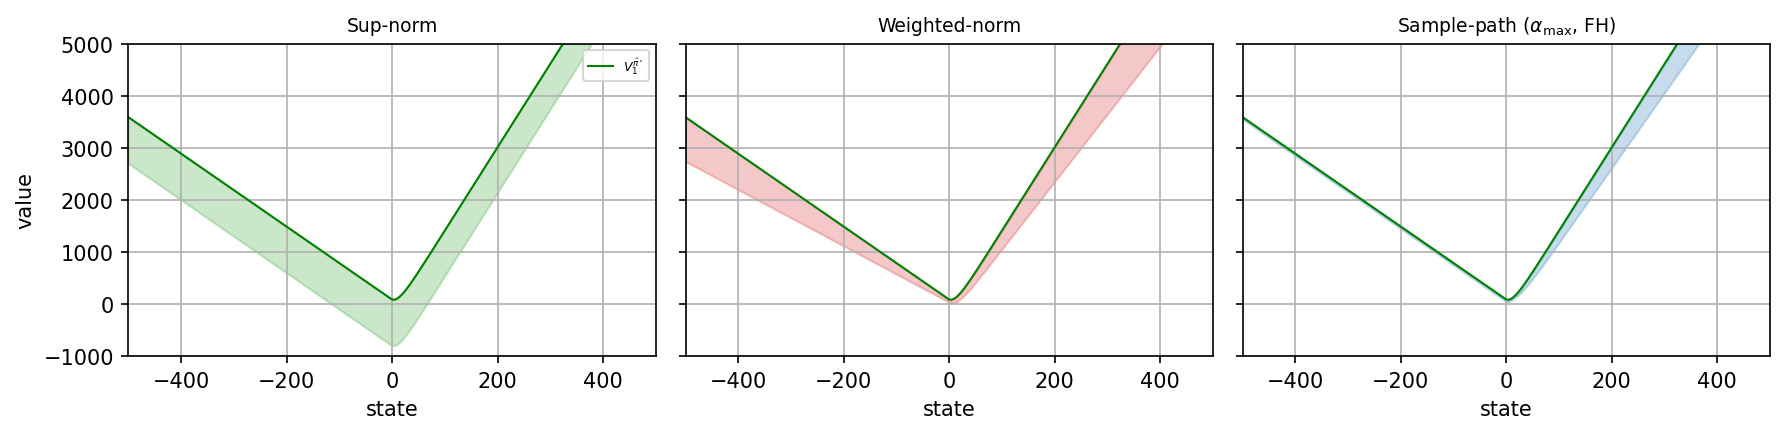

In [11]:
V_pi_hat_fh = V_pi_hat_fh_all[1]
V_star_fh = V_M_all[1]

plt.rcParams['pdf.fonttype'] = 42
fig, axes = plt.subplots(1, 3, figsize=(12, 3), dpi=150, sharey=True)

titles = ['Sup-norm', 'Weighted-norm', r'Sample-path ($\alpha_{\max}$, FH)']
bounds_list = [sup_bound_curve, weighted_bound_curve, 2 * alpha_max_fh]
colors = ['#2ca02c', '#d62728', '#1f77b4']

for ax, title, bound, clr in zip(axes, titles, bounds_list, colors):
    ax.plot(states, V_pi_hat_fh, linewidth=1, color='green',
            label=r'$V^{\hat\pi^\star}_1$')
    ax.fill_between(states, V_pi_hat_fh, V_pi_hat_fh - bound,
                     alpha=0.25, color=clr)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('state')
    ax.grid(True)
    ax.set_xlim(-s_max, s_max)
    ax.set_ylim(-1000, 5000)

axes[0].set_ylabel('value')
axes[0].legend(loc='best', fontsize=6)
plt.tight_layout()

os.makedirs('../figures/finite_horizon', exist_ok=True)
plt.savefig('../figures/finite_horizon/3panel_zoomed_out.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

### Plot 2: 4-Panel Shaded Regions (Zoomed In, includes $\alpha_{\text{restricted}}$)

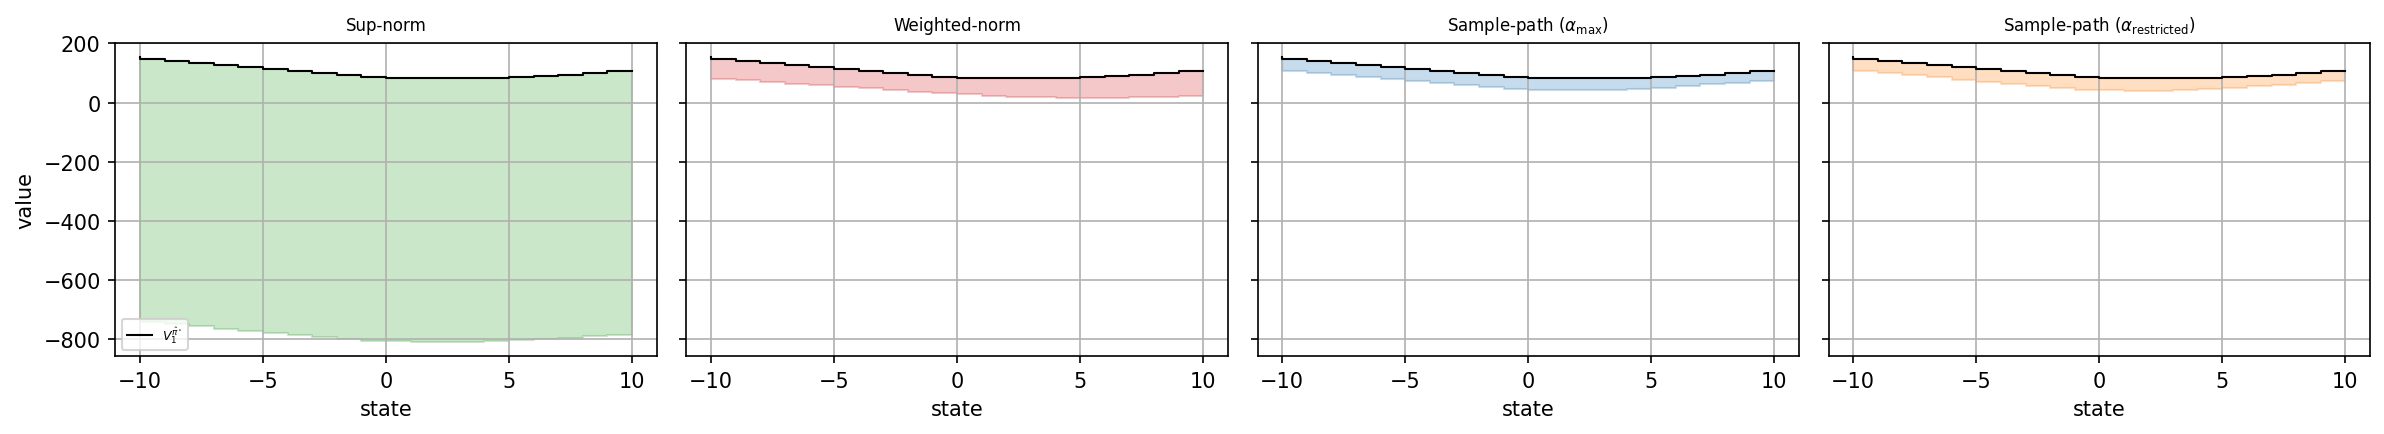

In [12]:
lo = s_max - 10
hi = s_max + 10 + 1

fig, axes = plt.subplots(1, 4, figsize=(16, 3), dpi=150, sharey=True)

titles_4 = ['Sup-norm', 'Weighted-norm',
            r'Sample-path ($\alpha_{\max}$)',
            r'Sample-path ($\alpha_{\mathrm{restricted}}$)']
bounds_4 = [sup_bound_curve, weighted_bound_curve,
            2 * alpha_max_fh, 2 * alpha_res_fh]
colors_4 = ['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e']

for ax, title, bound, clr in zip(axes, titles_4, bounds_4, colors_4):
    ax.step(states[lo:hi], V_pi_hat_fh[lo:hi], linewidth=1, color='black',
            label=r'$V^{\hat\pi^\star}_1$')
    ax.fill_between(states[lo:hi], V_pi_hat_fh[lo:hi],
                     V_pi_hat_fh[lo:hi] - bound[lo:hi],
                     alpha=0.25, color=clr, step='pre')
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('state')
    ax.grid(True)

axes[0].set_ylabel('value')
axes[0].legend(loc='best', fontsize=6)
plt.tight_layout()
plt.savefig('../figures/finite_horizon/4panel_zoomed_in.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

### Plot 3: Direct Bound Comparison (Zoomed In)

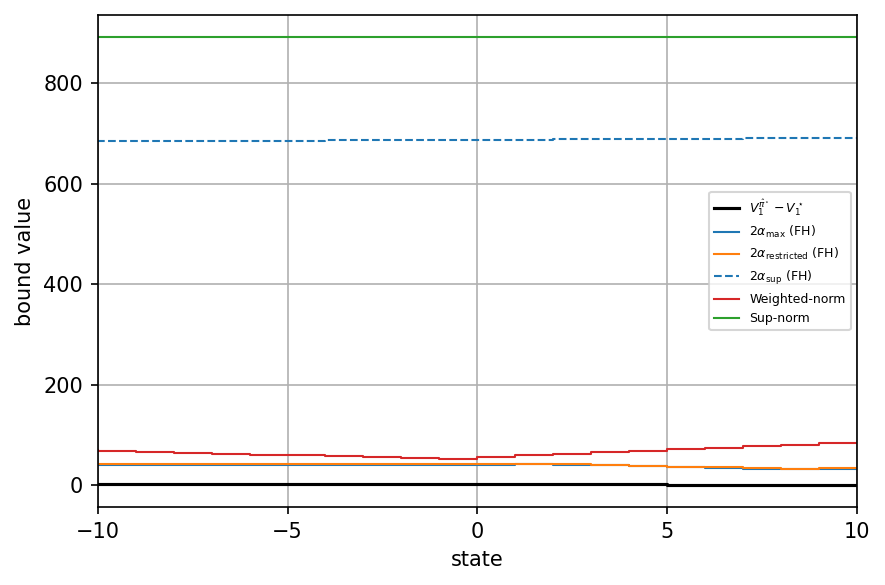

In [13]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.step(states[lo:hi], gap_fh[lo:hi], linewidth=1.5, color='black',
        label=r'$V^{\hat\pi^\star}_1 - V^\star_1$')
ax.step(states[lo:hi], 2 * alpha_max_fh[lo:hi], linewidth=1, color='#1f77b4',
        label=r'$2\alpha_{\max}$ (FH)')
ax.step(states[lo:hi], 2 * alpha_res_fh[lo:hi], linewidth=1, color='#ff7f0e',
        label=r'$2\alpha_{\mathrm{restricted}}$ (FH)')
ax.step(states[lo:hi], 2 * alpha_sup_fh[lo:hi], linewidth=1, color='#1f77b4',
        linestyle='--', label=r'$2\alpha_{\sup}$ (FH)')
ax.step(states[lo:hi], weighted_bound_curve[lo:hi], linewidth=1,
        color='#d62728', label='Weighted-norm')
ax.axhline(y=bound_sup, linewidth=1, color='#2ca02c', label='Sup-norm')

ax.set_xlabel('state')
ax.set_ylabel('bound value')
ax.set_xlim(-10, 10)
ax.set_xticks(np.arange(-10, 11, 5))
ax.legend(loc='best', fontsize=6)
ax.grid(True)
plt.tight_layout()
plt.savefig('../figures/finite_horizon/bound_comparison_zoomed_in.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

### Plot 3b: Sample-Path vs Weighted-Norm (Zoomed In, $s \in [-10, 10]$)

Overlaying both bounds on the same axes highlights the tightness difference. The shaded region shows the sample-path guaranteed region for $V^\star_1(s)$; the weighted-norm lower bound lies below, indicating a looser guarantee.

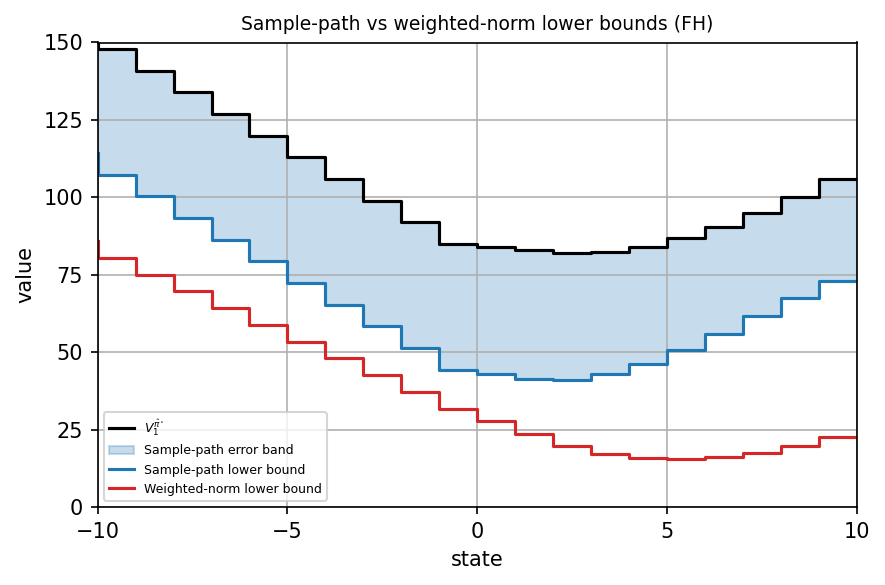

In [14]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

sp_lower = V_pi_hat_fh[lo:hi] - 2 * alpha_max_fh[lo:hi]
wn_lower = V_pi_hat_fh[lo:hi] - weighted_bound_curve[lo:hi]

# V^{pi_hat_star} on top
ax.step(states[lo:hi], V_pi_hat_fh[lo:hi], linewidth=1.5, color='black',
        label=r'$V^{\hat\pi^\star}_1$')

# Shaded region: sample-path error band
ax.fill_between(states[lo:hi], V_pi_hat_fh[lo:hi], sp_lower,
                alpha=0.25, color='#1f77b4', step='pre',
                label='Sample-path error band')

# Sample-path lower bound
ax.step(states[lo:hi], sp_lower, linewidth=1.5, color='#1f77b4',
        label='Sample-path lower bound')

# Weighted-norm lower bound
ax.step(states[lo:hi], wn_lower, linewidth=1.5, color='#d62728',
        label='Weighted-norm lower bound')

ax.set_xlabel('state')
ax.set_ylabel('value')
ax.set_title('Sample-path vs weighted-norm lower bounds (FH)', fontsize=9)
ax.legend(loc='lower left', fontsize=6)
ax.set_xticks(np.arange(-10, 11, 5))
ax.set_xlim(-10, 10)
ax.set_ylim(0, 150)
ax.set_yticks(np.arange(0, 151, 25))
ax.grid(True)
plt.tight_layout()
plt.savefig('../figures/finite_horizon/sp_vs_weighted_zoomed_in.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

### Plot 3b with Restricted: Overlay Including $\alpha_{\text{restricted}}$ (Zoomed In)

Same overlay as Plot 3b but adding the restricted action set bound as an additional line, showing it sits between $\alpha_{\max}$ and the weighted-norm bound.

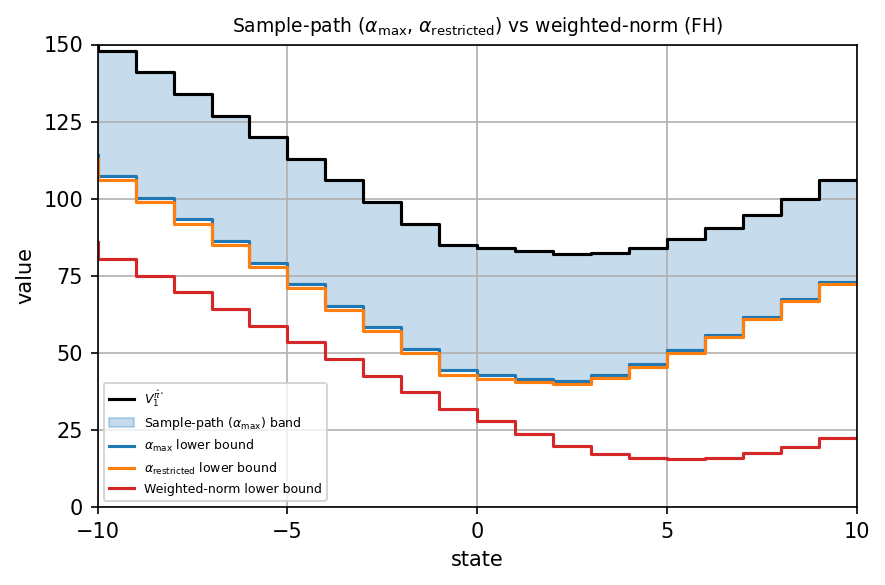

In [15]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

sp_lower = V_pi_hat_fh[lo:hi] - 2 * alpha_max_fh[lo:hi]
sp_restr_lower = V_pi_hat_fh[lo:hi] - 2 * alpha_res_fh[lo:hi]
wn_lower = V_pi_hat_fh[lo:hi] - weighted_bound_curve[lo:hi]

# V^{pi_hat_star} on top
ax.step(states[lo:hi], V_pi_hat_fh[lo:hi], linewidth=1.5, color='black',
        label=r'$V^{\hat\pi^\star}_1$')

# Shaded region: sample-path (alpha_max) error band
ax.fill_between(states[lo:hi], V_pi_hat_fh[lo:hi], sp_lower,
                alpha=0.25, color='#1f77b4', step='pre',
                label=r'Sample-path ($\alpha_{\max}$) band')

# Lower bound lines
ax.step(states[lo:hi], sp_lower, linewidth=1.5, color='#1f77b4',
        label=r'$\alpha_{\max}$ lower bound')
ax.step(states[lo:hi], sp_restr_lower, linewidth=1.5, color='#ff7f0e',
        label=r'$\alpha_{\mathrm{restricted}}$ lower bound')
ax.step(states[lo:hi], wn_lower, linewidth=1.5, color='#d62728',
        label='Weighted-norm lower bound')

ax.set_xlabel('state')
ax.set_ylabel('value')
ax.set_title(r'Sample-path ($\alpha_{\max}$, $\alpha_{\mathrm{restricted}}$) vs weighted-norm (FH)', fontsize=9)
ax.legend(loc='lower left', fontsize=6)
ax.set_xticks(np.arange(-10, 11, 5))
ax.set_xlim(-10, 10)
ax.set_ylim(0, 150)
ax.set_yticks(np.arange(0, 151, 25))
ax.grid(True)
plt.tight_layout()
plt.savefig('../figures/finite_horizon/sp_vs_weighted_restricted_zoomed_in.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

### Plot 4: Finite-Horizon vs Infinite-Horizon Overlay

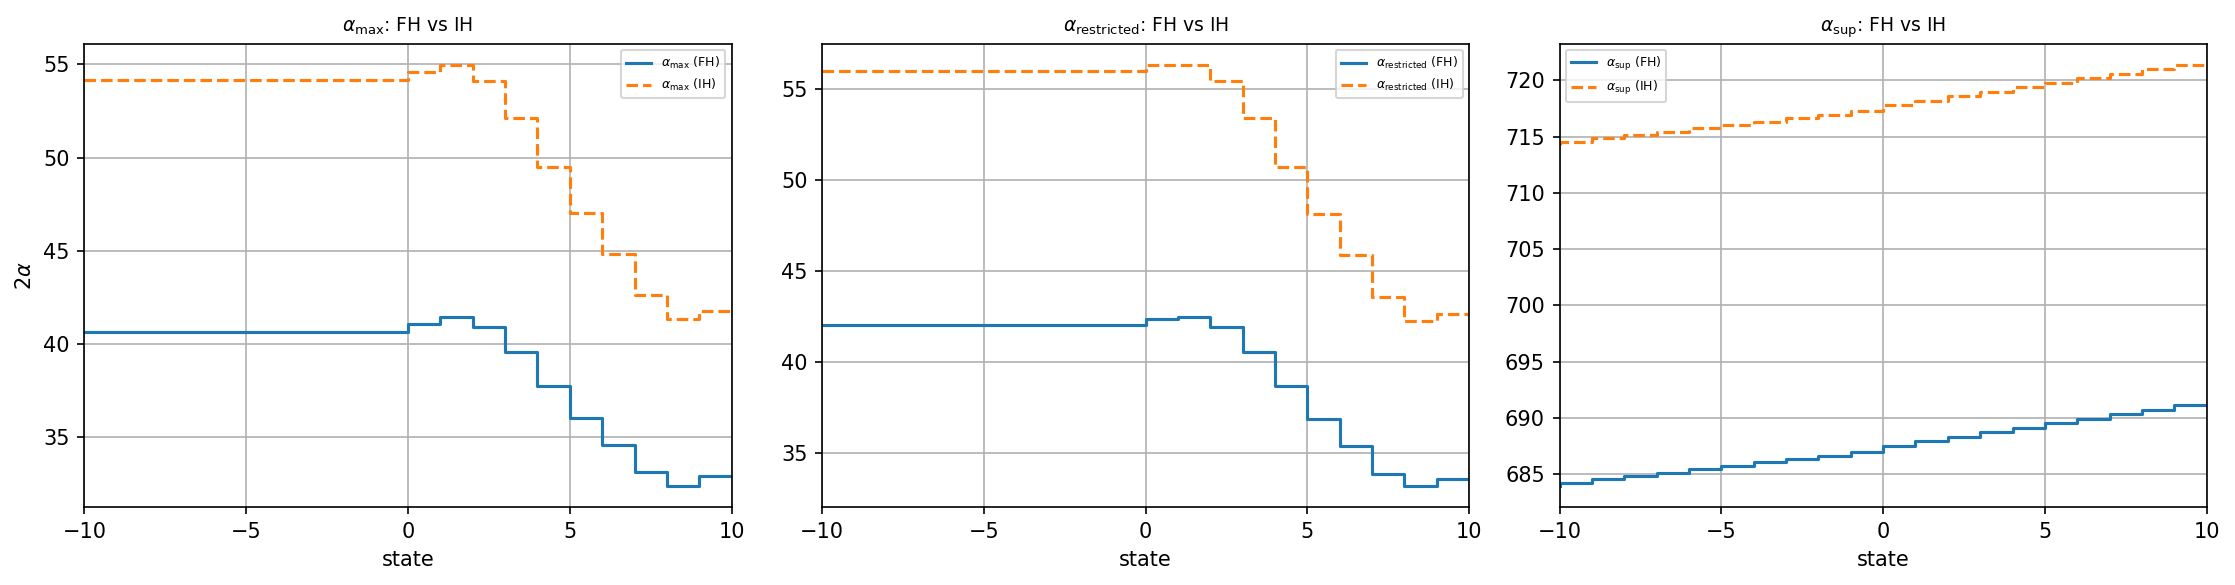

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)

pairs = [
    (alpha_max_fh, alpha_max_ih, r'$\alpha_{\max}$'),
    (alpha_res_fh, alpha_res_ih, r'$\alpha_{\mathrm{restricted}}$'),
    (alpha_sup_fh, alpha_sup_ih, r'$\alpha_{\sup}$'),
]

for ax, (a_fh, a_ih, lbl) in zip(axes, pairs):
    ax.step(states[lo:hi], 2 * a_fh[lo:hi], linewidth=1.5, color='#1f77b4',
            label=f'{lbl} (FH)')
    ax.step(states[lo:hi], 2 * a_ih[lo:hi], linewidth=1.5, color='#ff7f0e',
            linestyle='--', label=f'{lbl} (IH)')
    ax.set_title(f'{lbl}: FH vs IH', fontsize=9)
    ax.set_xlabel('state')
    ax.legend(loc='best', fontsize=6)
    ax.grid(True)
    ax.set_xlim(-10, 10)
    ax.set_xticks(np.arange(-10, 11, 5))

axes[0].set_ylabel('$2\\alpha$')
plt.tight_layout()
plt.savefig('../figures/finite_horizon/fh_vs_ih_overlay.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

### Plot 5: Error Decomposition at $t=1$

At the first time step, $\alpha_1(s) = \varepsilon_1(s) + H^{(1)}_\alpha[s + \hat\pi^\star_1(s)] + H^{(1)}_\Delta[s + \hat\pi^\star_1(s)]$.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


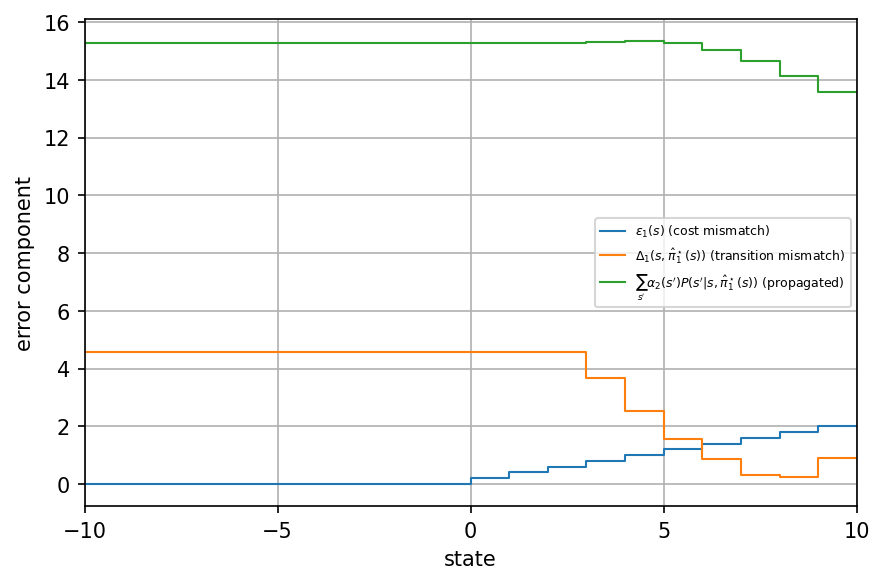

In [17]:
# Recompute decomposition at t=1 for alpha_max
W_M = M.W
W_Mh = M_hat.W
n_demand = len(W_M)
H_len = 3 * s_max + 1

epsilon_base = np.abs(M.h_vec(states) - M_hat.h_vec(states))
eps_1 = epsilon_base  # gamma^0 = 1

# H_delta at t=1 uses V_Mhat[2]
V_Mhat_2 = V_Mhat_all[2]
H_M_v = np.zeros(H_len)
H_Mh_v = np.zeros(H_len)
for z in range(-s_max, 2 * s_max + 1):
    for w in range(n_demand):
        ns_idx = min(max(z - w, -s_max), s_max)
        H_M_v[z + s_max] += W_M[w] * V_Mhat_2[ns_idx + s_max]
        H_Mh_v[z + s_max] += W_Mh[w] * V_Mhat_2[ns_idx + s_max]
H_delta_1 = np.abs(H_M_v - H_Mh_v)

# H_alpha at t=1 uses alpha_max[2]
alpha_2 = alpha_max_fh_all[2]
H_alpha_1 = np.zeros(H_len)
for z in range(-s_max, 2 * s_max + 1):
    for w in range(n_demand):
        ns_idx = min(max(z - w, -s_max), s_max)
        H_alpha_1[z + s_max] += W_M[w] * alpha_2[ns_idx + s_max]

# Components at pi_Mhat[1, :]
delta_at_pi_hat = np.zeros(num_states)
propagated = np.zeros(num_states)
for si in range(num_states):
    s_int = si - s_max
    a = pi_Mhat_all[1, si]
    z_idx = min(s_int + a, 2 * s_max) + s_max
    delta_at_pi_hat[si] = H_delta_1[z_idx]
    propagated[si] = H_alpha_1[z_idx]

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.step(states[lo:hi], eps_1[lo:hi], linewidth=1, color='#1f77b4',
        label=r'$\varepsilon_1(s)$ (cost mismatch)')
ax.step(states[lo:hi], delta_at_pi_hat[lo:hi], linewidth=1, color='#ff7f0e',
        label=r'$\Delta_1(s, \hat\pi^\star_1(s))$ (transition mismatch)')
ax.step(states[lo:hi], propagated[lo:hi], linewidth=1, color='#2ca02c',
        label=r'$\sum_{s^\prime} \alpha_2(s^\prime) P(s^\prime|s,\hat\pi^\star_1(s))$ (propagated)')

ax.set_xlabel('state')
ax.set_ylabel('error component')
ax.set_xlim(-10, 10)
ax.set_xticks(np.arange(-10, 11, 5))
ax.legend(loc='best', fontsize=6)
ax.grid(True)
plt.tight_layout()
plt.savefig('../figures/finite_horizon/error_decomposition_t1.pdf',
            format='pdf', bbox_inches='tight')
plt.show()

## 7. Summary Table

Comparison of bounding methods in the operating region $s \in \{-7, \ldots, 3\}$.

In [18]:
op_lo = s_max - 7
op_hi = s_max + 3 + 1

print(f'{"Method":<35s} {"Max in [-7,3]":>15s} {"Max (all s)":>15s}')
print('-' * 67)
print(f'{"True gap":<35s} {np.max(gap_fh[op_lo:op_hi]):>15.4f} {np.max(gap_fh):>15.4f}')
print(f'{"2*alpha_max (FH, sample-path)":<35s} {np.max(2*alpha_max_fh[op_lo:op_hi]):>15.4f} {np.max(2*alpha_max_fh):>15.4f}')
print(f'{"2*alpha_restricted (FH, sp)":<35s} {np.max(2*alpha_res_fh[op_lo:op_hi]):>15.4f} {np.max(2*alpha_res_fh):>15.4f}')
print(f'{"2*alpha_sup (FH, sample-path)":<35s} {np.max(2*alpha_sup_fh[op_lo:op_hi]):>15.4f} {np.max(2*alpha_sup_fh):>15.4f}')
print(f'{"2*alpha_max (IH, sample-path)":<35s} {np.max(2*alpha_max_ih[op_lo:op_hi]):>15.4f} {np.max(2*alpha_max_ih):>15.4f}')
print(f'{"2*alpha_restricted (IH, sp)":<35s} {np.max(2*alpha_res_ih[op_lo:op_hi]):>15.4f} {np.max(2*alpha_res_ih):>15.4f}')
print(f'{"2*alpha_sup (IH, sample-path)":<35s} {np.max(2*alpha_sup_ih[op_lo:op_hi]):>15.4f} {np.max(2*alpha_sup_ih):>15.4f}')
print(f'{"Weighted-norm":<35s} {np.max(weighted_bound_curve[op_lo:op_hi]):>15.4f} {np.max(weighted_bound_curve):>15.4f}')
print(f'{"Sup-norm":<35s} {bound_sup:>15.4f} {bound_sup:>15.4f}')
print()
print('Tightness ratios in [-7, 3]:')
print(f'  FH alpha_max / weighted = {np.max(2*alpha_max_fh[op_lo:op_hi]) / np.max(weighted_bound_curve[op_lo:op_hi]):.4f}')
print(f'  FH alpha_res / weighted = {np.max(2*alpha_res_fh[op_lo:op_hi]) / np.max(weighted_bound_curve[op_lo:op_hi]):.4f}')
print(f'  FH alpha_max / sup-norm = {np.max(2*alpha_max_fh[op_lo:op_hi]) / bound_sup:.4f}')

Method                                Max in [-7,3]     Max (all s)
-------------------------------------------------------------------
True gap                                     2.0112          2.0112
2*alpha_max (FH, sample-path)               41.4470        872.0000
2*alpha_restricted (FH, sp)                 42.4589        872.0000
2*alpha_sup (FH, sample-path)              688.3304        887.1304
2*alpha_max (IH, sample-path)               54.9751        902.4000
2*alpha_restricted (IH, sp)                 56.3427        902.4000
2*alpha_sup (IH, sample-path)              718.5762        917.3762
Weighted-norm                               64.3218       1568.1770
Sup-norm                                   891.2000        891.2000

Tightness ratios in [-7, 3]:
  FH alpha_max / weighted = 0.6444
  FH alpha_res / weighted = 0.6601
  FH alpha_max / sup-norm = 0.0465


## 8. Paper Figures

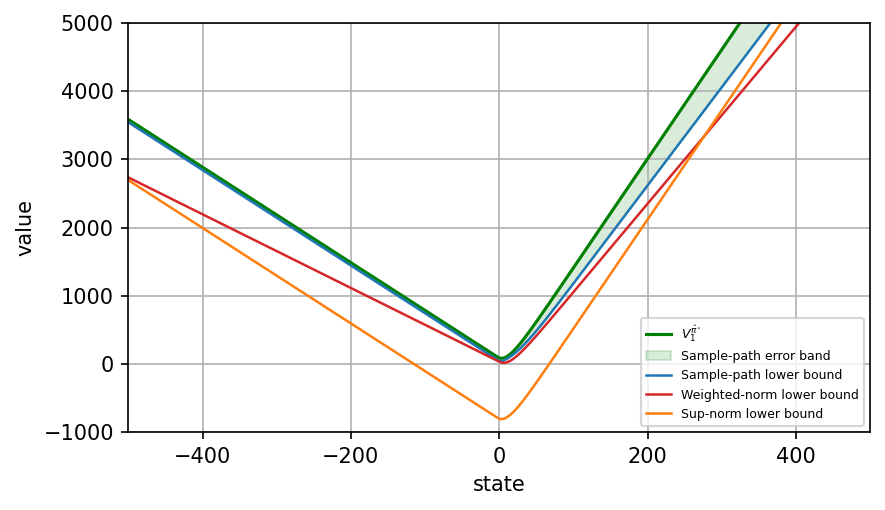

Saved figures/fh_bounds_comparison_out.pdf


In [19]:
# --- Figure 1a: Lower bound comparison (zoomed out, full state space) ---
plt.rcParams['pdf.fonttype'] = 42

sp_lower  = V_pi_hat_fh - 2 * alpha_res_fh
wn_lower  = V_pi_hat_fh - weighted_bound_curve
sn_lower  = V_pi_hat_fh - bound_sup

tightest_lower = np.maximum(np.maximum(sp_lower, wn_lower), sn_lower)

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=150)

ax.plot(states, V_pi_hat_fh, linewidth=1.5, color='green',
        label=r'$V^{\hat\pi^\star}_1$')
ax.fill_between(states, V_pi_hat_fh, tightest_lower,
                alpha=0.15, color='green', label='Sample-path error band')
ax.plot(states, sp_lower, linewidth=1.2, color='#1f77b4',
        label='Sample-path lower bound')
ax.plot(states, wn_lower, linewidth=1.2, color='#d62728',
        label='Weighted-norm lower bound')
ax.plot(states, sn_lower, linewidth=1.2, color='#ff7f0e',
        label='Sup-norm lower bound')

ax.set_xlabel('state')
ax.set_ylabel('value')
ax.set_xlim(-s_max, s_max)
ax.set_ylim(-1000, 5000)
ax.legend(loc='best', fontsize=6)
ax.grid(True)
plt.tight_layout()

os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/fh_bounds_comparison_out.pdf',
            format='pdf', bbox_inches='tight')
plt.show()
print('Saved figures/fh_bounds_comparison_out.pdf')

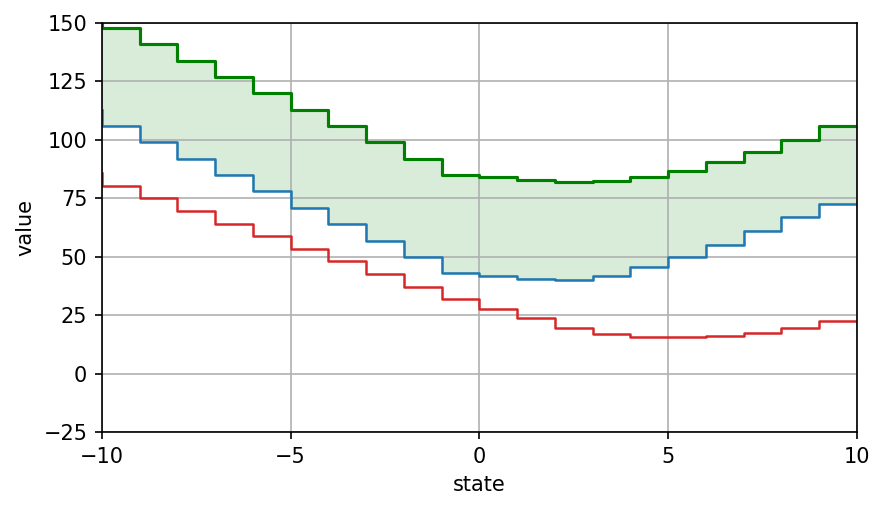

Saved figures/fh_bounds_comparison_in.pdf


In [20]:
# --- Figure 1b: Lower bound comparison (zoomed in, operating region) ---
lo_fig = s_max - 10
hi_fig = s_max + 10 + 1

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=150)

ax.step(states[lo_fig:hi_fig], V_pi_hat_fh[lo_fig:hi_fig], linewidth=1.5,
        color='green', label=r'$V^{\hat\pi^\star}_1$')
ax.fill_between(states[lo_fig:hi_fig], V_pi_hat_fh[lo_fig:hi_fig],
                tightest_lower[lo_fig:hi_fig],
                alpha=0.15, color='green', step='pre',
                label='Sample-path error band')
ax.step(states[lo_fig:hi_fig], sp_lower[lo_fig:hi_fig], linewidth=1.2,
        color='#1f77b4', label='Sample-path lower bound')
ax.step(states[lo_fig:hi_fig], wn_lower[lo_fig:hi_fig], linewidth=1.2,
        color='#d62728', label='Weighted-norm lower bound')
ax.step(states[lo_fig:hi_fig], sn_lower[lo_fig:hi_fig], linewidth=1.2,
        color='#ff7f0e', label='Sup-norm lower bound')

ax.set_xlabel('state')
ax.set_ylabel('value')
ax.set_xlim(-10, 10)
ax.set_xticks(np.arange(-10, 11, 5))
ax.set_ylim(-25, 150)
ax.set_yticks(np.arange(-25, 151, 25))
ax.grid(True)
plt.tight_layout()

plt.savefig('../figures/fh_bounds_comparison_in.pdf',
            format='pdf', bbox_inches='tight')
plt.show()
print('Saved figures/fh_bounds_comparison_in.pdf')

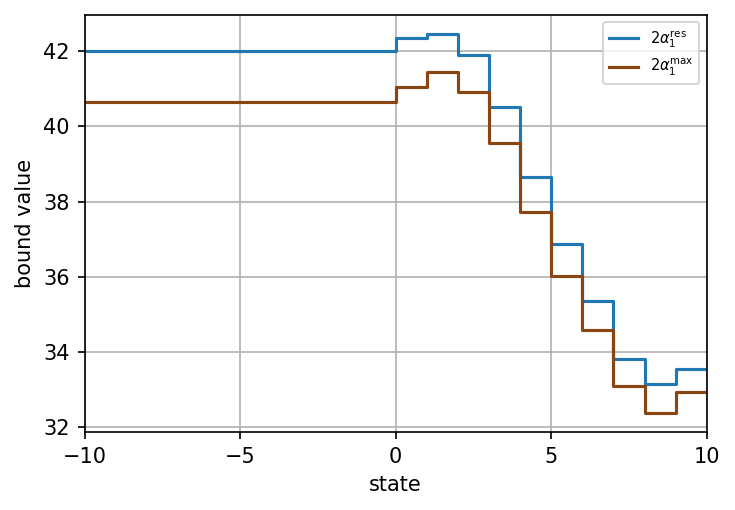

Saved figures/fh_max_vs_res.pdf


In [21]:
# --- Figure 2: alpha_max vs alpha_res (zoomed in) ---
plt.rcParams['pdf.fonttype'] = 42

lo = s_max - 10
hi = s_max + 10 + 1

fig, ax = plt.subplots(figsize=(5, 3.5), dpi=150)

ax.step(states[lo:hi], 2 * alpha_res_fh[lo:hi], linewidth=1.5,
        color='#1f77b4', label=r'$2\alpha^{\mathrm{res}}_1$')
ax.step(states[lo:hi], 2 * alpha_max_fh[lo:hi], linewidth=1.5,
        color='#8B4513', label=r'$2\alpha^{\max}_1$')

ax.set_xlabel('state')
ax.set_ylabel('bound value')
ax.set_xlim(-10, 10)
ax.set_xticks(np.arange(-10, 11, 5))
ax.legend(loc='best', fontsize=7)
ax.grid(True)
plt.tight_layout()

plt.savefig('../figures/fh_max_vs_res.pdf',
            format='pdf', bbox_inches='tight')
plt.show()
print('Saved figures/fh_max_vs_res.pdf')

## 8. Comparing Restricted Action Set Formulations

**Set 1 (current):**
$$A_1(s) = \{\max(0, \sigma - s) : \sigma \in \{0, \ldots, n\}\} \cup \{\hat\pi^\star_t(s)\}$$

**Set 2 (simpler):**
$$A_2(s) = \{0, 1, \ldots, \max(0, n - s)\} \cup \{\hat\pi^\star_t(s)\}$$

These are identical for $s \geq 0$ but differ for $s < 0$:
- Set 1 at $s < 0$: actions $\{|s|, |s|+1, \ldots, n+|s|\}$ (base-stock levels $0, \ldots, n$), giving $z \in \{0, 1, \ldots, n\}$
- Set 2 at $s < 0$: actions $\{0, 1, \ldots, n+|s|\}$ (includes extra small actions), giving $z \in \{s, s+1, \ldots, n\}$

Set 2 is a superset of Set 1, so $\alpha_{\text{Set 1}}(s) \leq \alpha_{\text{Set 2}}(s)$.

In [22]:
def fh_sample_path_bound_set2(M, M_hat, V_Mhat_all, pi_Mhat_all, T):
    """Alpha_restricted using Set 2: A(s) = {0, ..., max(0, n-s)} union {pi_hat(s)}.
    
    Only difference from Set 1: for s < 0, z ranges over {s, ..., n}
    instead of just the base-stock levels {0, ..., n}.
    """
    sm = M.s_max
    gam = M.gamma
    W_M = M.W
    W_Mh = M_hat.W
    n_demand = len(W_M)
    n = M.n
    ns = M.num_states
    H_len = 3 * sm + 1
    st = M.states

    h_M = M.h_vec(st)
    h_Mh = M_hat.h_vec(st)
    epsilon_base = np.abs(h_M - h_Mh)

    alpha_set2_all = np.zeros((T + 1, ns))
    gamma_T = gam ** (T - 1)
    alpha_set2_all[T, :] = gamma_T * epsilon_base

    H_M_v = np.zeros(H_len)
    H_Mh_v = np.zeros(H_len)

    for t in range(T - 1, 0, -1):
        gamma_t = gam ** (t - 1)
        eps_t = gamma_t * epsilon_base

        V_Mhat_next = V_Mhat_all[t + 1]

        # Build H_M and H_Mhat on V_Mhat_{t+1}
        for z in range(-sm, 2 * sm + 1):
            H_M_v[z + sm] = 0.0
            H_Mh_v[z + sm] = 0.0
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                H_M_v[z + sm] += W_M[w] * V_Mhat_next[ns_idx + sm]
                H_Mh_v[z + sm] += W_Mh[w] * V_Mhat_next[ns_idx + sm]
        H_delta = np.abs(H_M_v - H_Mh_v)

        # Build H_alpha on alpha_set2[t+1]
        alpha_next = alpha_set2_all[t + 1]
        H_alpha = np.zeros(H_len)
        for z in range(-sm, 2 * sm + 1):
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                H_alpha[z + sm] += W_M[w] * alpha_next[ns_idx + sm]

        combo = H_alpha + H_delta

        for si in range(ns):
            s_int = si - sm
            if s_int >= n:
                # a=0 only, z=s
                best_combo = combo[s_int + sm]
            else:
                # Set 2: z in {s, s+1, ..., n}  (unified for s<0 and 0<=s<n)
                z_lo = s_int + sm
                z_hi = n + sm
                best_combo = np.max(combo[z_lo:z_hi + 1])

            # Also include pi_hat(s)
            a_hat = pi_Mhat_all[t, si]
            z_hat = min(s_int + a_hat, 2 * sm) + sm
            best_combo = max(best_combo, combo[z_hat])

            alpha_set2_all[t, si] = eps_t[si] + best_combo

    return alpha_set2_all

print('Running Set 2 restricted bound ...')
alpha_set2_all = fh_sample_path_bound_set2(M, M_hat, V_Mhat_all, pi_Mhat_all, T)
alpha_set2_fh = alpha_set2_all[1]

print(f'max 2*alpha_set1 = {2*np.max(alpha_res_fh):.4f}')
print(f'max 2*alpha_set2 = {2*np.max(alpha_set2_fh):.4f}')

Running Set 2 restricted bound ...


max 2*alpha_set1 = 872.0000
max 2*alpha_set2 = 872.0000


In [23]:
# --- Comparison ---
diff = alpha_set2_fh - alpha_res_fh  # should be >= 0 (Set 2 is superset)
print(f'max |alpha_set2 - alpha_set1|       = {np.max(np.abs(diff)):.6e}')
print(f'min (alpha_set2 - alpha_set1)       = {np.min(diff):.6e}  (should be >= 0)')
print(f'max (alpha_set2 - alpha_set1)       = {np.max(diff):.6e}')
print()

# Where do they differ?  Only at s < 0
neg_mask = states < 0
pos_mask = states >= 0
print(f'max diff at s >= 0: {np.max(np.abs(diff[pos_mask])):.6e}')
print(f'max diff at s <  0: {np.max(np.abs(diff[neg_mask])):.6e}')
print()

# Operating region
op_lo = s_max - 7
op_hi = s_max + 3 + 1
diff_op = np.max(np.abs(diff[op_lo:op_hi]))
print(f'max |diff| in [-7, 3]:  {diff_op:.6e}')
print(f'max 2*alpha_set1 in [-7,3]: {np.max(2*alpha_res_fh[op_lo:op_hi]):.4f}')
print(f'max 2*alpha_set2 in [-7,3]: {np.max(2*alpha_set2_fh[op_lo:op_hi]):.4f}')

# Validity check: Set 2 should still be a valid bound
slack_set2 = 2 * alpha_set2_fh - gap_fh
print(f'\nmin slack (2*alpha_set2 - gap) = {np.min(slack_set2):.6f}')
print(f'Set 2 bound valid: {np.all(slack_set2 >= -1e-8)}')

# Ordering: alpha_max <= alpha_set1 <= alpha_set2 <= alpha_sup
print(f'\nalpha_max <= alpha_set1 <= alpha_set2 <= alpha_sup:')
print(f'  max(alpha_max - alpha_set1): {np.max(alpha_max_fh - alpha_res_fh):.2e}')
print(f'  max(alpha_set1 - alpha_set2): {np.max(alpha_res_fh - alpha_set2_fh):.2e}')
print(f'  max(alpha_set2 - alpha_sup):  {np.max(alpha_set2_fh - alpha_sup_fh):.2e}')

max |alpha_set2 - alpha_set1|       = 1.848336e-02
min (alpha_set2 - alpha_set1)       = 0.000000e+00  (should be >= 0)
max (alpha_set2 - alpha_set1)       = 1.848336e-02

max diff at s >= 0: 4.618528e-14
max diff at s <  0: 1.848336e-02

max |diff| in [-7, 3]:  7.105427e-14
max 2*alpha_set1 in [-7,3]: 42.4589
max 2*alpha_set2 in [-7,3]: 42.4589

min slack (2*alpha_set2 - gap) = 32.086264
Set 2 bound valid: True

alpha_max <= alpha_set1 <= alpha_set2 <= alpha_sup:
  max(alpha_max - alpha_set1): 0.00e+00
  max(alpha_set1 - alpha_set2): 0.00e+00
  max(alpha_set2 - alpha_sup):  -7.57e+00


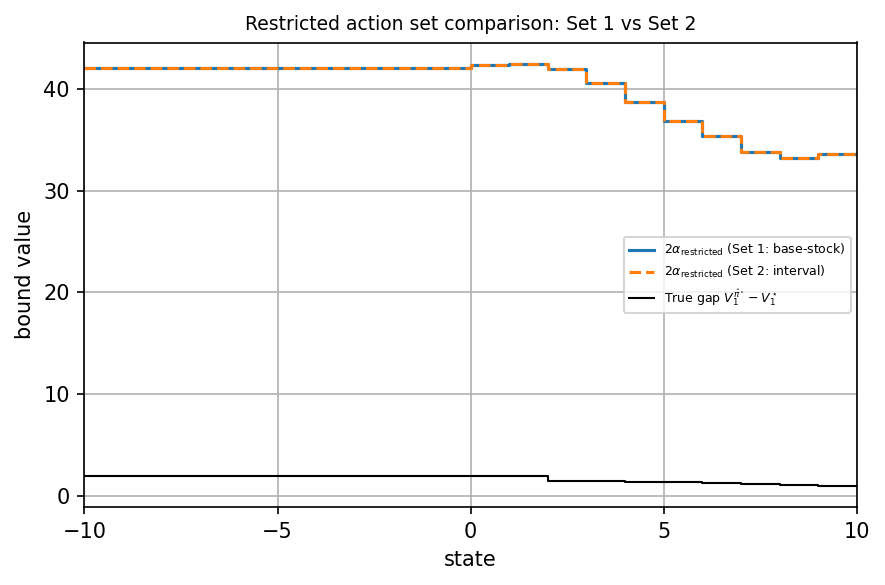

In [24]:
# --- Plot: Set 1 vs Set 2 (zoomed in, s in [-10, 10]) ---
lo = s_max - 10
hi = s_max + 10 + 1

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.step(states[lo:hi], 2 * alpha_res_fh[lo:hi], linewidth=1.5, color='#1f77b4',
        label=r'$2\alpha_{\mathrm{restricted}}$ (Set 1: base-stock)')
ax.step(states[lo:hi], 2 * alpha_set2_fh[lo:hi], linewidth=1.5, color='#ff7f0e',
        linestyle='--', label=r'$2\alpha_{\mathrm{restricted}}$ (Set 2: interval)')
ax.step(states[lo:hi], gap_fh[lo:hi], linewidth=1, color='black',
        label=r'True gap $V^{\hat\pi^\star}_1 - V^\star_1$')

ax.set_xlabel('state')
ax.set_ylabel('bound value')
ax.set_title('Restricted action set comparison: Set 1 vs Set 2', fontsize=9)
ax.legend(loc='best', fontsize=6)
ax.set_xlim(-10, 10)
ax.set_xticks(np.arange(-10, 11, 5))
ax.grid(True)
plt.tight_layout()
plt.show()

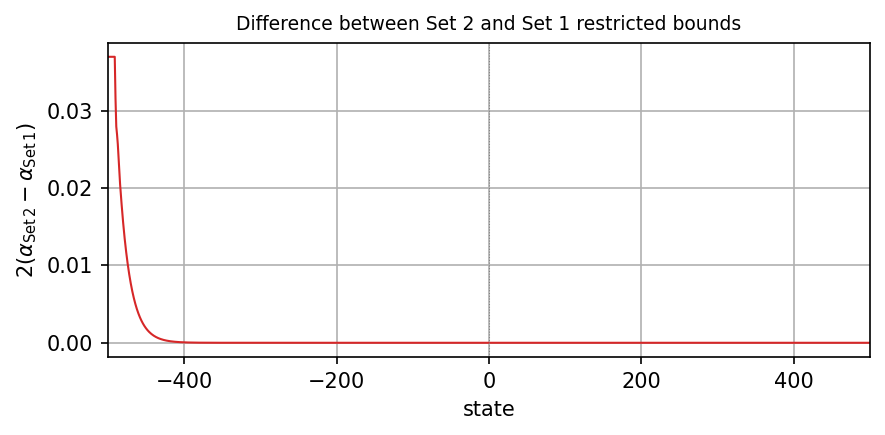

In [25]:
# --- Plot: difference alpha_set2 - alpha_set1 (full state range) ---
fig, ax = plt.subplots(figsize=(6, 3), dpi=150)

ax.plot(states, 2 * diff, linewidth=1, color='#d62728')
ax.axvline(x=0, color='gray', linestyle=':', linewidth=0.5)
ax.set_xlabel('state')
ax.set_ylabel(r'$2(\alpha_{\mathrm{Set\,2}} - \alpha_{\mathrm{Set\,1}})$')
ax.set_title('Difference between Set 2 and Set 1 restricted bounds', fontsize=9)
ax.set_xlim(-s_max, s_max)
ax.grid(True)
plt.tight_layout()
plt.show()

## 9. Signed Sample-Path Bound (Extended Theorem 3 / 4)

The absolute-value bound above certifies $|V^{\hat\pi^\star}-V^\star|\le 2\alpha$. The **signed** bound (Extended Theorem 3) drops the absolute values and instead tracks two *signed* error streams that share the baseline $\hat V^\star$:

- **Policy-evaluation stream** $\alpha^{\hat\pi^\star}_t(s)=V^{\hat\pi^\star}_t-\hat V^\star_t$ — an **exact** recursion (Lemma 1), anchored at the single known action $\hat\pi^\star_t(s)$ (no action search).
- **Optimality stream** $\alpha^\star_t(s)=V^\star_t-\hat V^\star_t$ — a **sub-solution** (Lemma 2, Eq. 20). Since it must satisfy $\alpha^\star_t\le\beta^\star_t(s,\pi^\star_t(s))$, we take a **`min`** over a candidate set guaranteed to contain $\pi^\star(s)$.

The signed transition/cost mismatches $\Delta_t$ keep their sign (no `abs`). The upper bound at $t=1$ is

$$V^{\hat\pi^\star}(s)-V^\star(s)\ \le\ U(s)=\alpha^{\hat\pi^\star}_1(s)-\alpha^\star_1(s).$$

Three variants differ **only** in the candidate set of the `min` in the optimality stream:

| variant | candidate set | needs true $\pi^\star$? |
|---|---|---|
| `U_max` | the true optimal action $\pi^\star(s)$ | **yes** |
| `U_res` | base-stock set $\{\max(s,\sigma):\sigma\in\Sigma\}$, capped to feasible $a\le s_{\max}$ | **no** (only $\Sigma$) |
| `U_sup` | all actions | no |

Because `min` over a smaller set is larger, $\alpha^\star_{\max}\ge\alpha^\star_{\mathrm{res}}\ge\alpha^\star_{\sup}$, giving the ordering $U_{\max}\le U_{\mathrm{res}}\le U_{\sup}$ — the same direction as the absolute-value variants.

**Lower edge (Extended Theorem 4, Eq. 34).** The computable in-framework lower bound collapses to $V^{\hat\pi^\star}-V^\star\ge 0$ (the optimality super-solution anchored at $\hat\pi^\star$ coincides with the policy-evaluation stream). A *non-trivial* lower edge requires the true-model advantage of $\hat\pi^\star$:
$$V^{\hat\pi^\star}(s)-V^\star(s)\ \ge\ L(s)=Q^{\hat\pi^\star}(s,\hat\pi^\star)-Q^\star(s,\hat\pi^\star)=V^{\hat\pi^\star}_1(s)-Q^\star_1(s,\hat\pi^\star(s)),$$
which needs $V^\star$, so it is **demonstrative** (shown here because we solve the true model anyway).

In [26]:
# =====================================================================
# Signed sample-path bound (Extended Theorem 3)
# =====================================================================
def finite_horizon_signed_bound(M, M_hat, V_Mhat_all, pi_M_all,
                                pi_Mhat_all, T, Sigma=None):
    """Signed bound (Extended Thm 3). Two streams share the baseline V_hat*:

      alpha_pihat : EXACT policy-evaluation error of pi_hat* (Lemma 1),
                    anchored at the single action pi_hat*(s) -- no search.
      alpha_star  : optimality-gap SUB-solution (Lemma 2 / Eq.20). Because we
                    need alpha_star <= beta*(s, pi*(s)) we take a MIN over a
                    candidate set guaranteed to contain pi*(s).

    No absolute values: eps and Hdelta are signed.

    star-stream variants (only the candidate set of the MIN changes):
      _max : the true optimal action pi_M(s)            (needs true pi*)
      _res : base-stock set {max(s,sigma)} capped feasible (needs only Sigma)
      _sup : all actions                                (needs nothing)

    Upper bound at t=1:  U(s) = alpha_pihat_1(s) - alpha_star_1(s).

    Returns: alpha_pihat_all, alpha_star_max_all,
             alpha_star_res_all, alpha_star_sup_all   (each (T+1, ns))
    """
    sm = M.s_max; gam = M.gamma
    W_M = M.W; W_Mh = M_hat.W
    n_demand = len(W_M); n = M.n
    ns = M.num_states; H_len = 3 * sm + 1
    st = M.states

    if Sigma is None:
        Sigma = list(range(0, n + 1))
    Sigma_arr = np.array(Sigma, dtype=int)

    eps_signed_base = M.h_vec(st) - M_hat.h_vec(st)   # SIGNED (no abs)

    def propagate(vec):
        """H[z] = sum_w W_M[w] * vec(clip(z - w)) on the TRUE kernel."""
        Hv = np.zeros(H_len)
        for z in range(-sm, 2 * sm + 1):
            acc = 0.0
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                acc += W_M[w] * vec[ns_idx + sm]
            Hv[z + sm] = acc
        return Hv

    a_ph = np.zeros((T + 1, ns))   # policy-evaluation stream
    a_mx = np.zeros((T + 1, ns))   # optimality stream, max-analog
    a_rs = np.zeros((T + 1, ns))   # optimality stream, restricted
    a_sp = np.zeros((T + 1, ns))   # optimality stream, sup

    # Terminal: Delta_T = gamma^{T-1}*(h_M - h_Mh), action-independent.
    term = (gam ** (T - 1)) * eps_signed_base
    a_ph[T] = a_mx[T] = a_rs[T] = a_sp[T] = term

    for t in range(T - 1, 0, -1):
        eps_t = (gam ** (t - 1)) * eps_signed_base

        # signed transition mismatch on V_hat*_{t+1}
        Vn = V_Mhat_all[t + 1]
        H_M_v = np.zeros(H_len); H_Mh_v = np.zeros(H_len)
        for z in range(-sm, 2 * sm + 1):
            am = ah = 0.0
            for w in range(n_demand):
                ns_idx = min(max(z - w, -sm), sm)
                am += W_M[w] * Vn[ns_idx + sm]
                ah += W_Mh[w] * Vn[ns_idx + sm]
            H_M_v[z + sm] = am; H_Mh_v[z + sm] = ah
        Hdelta = H_M_v - H_Mh_v                       # SIGNED

        combo_ph = Hdelta + propagate(a_ph[t + 1])
        combo_mx = Hdelta + propagate(a_mx[t + 1])
        combo_rs = Hdelta + propagate(a_rs[t + 1])
        combo_sp = Hdelta + propagate(a_sp[t + 1])

        for si in range(ns):
            s_int = si - sm

            # pi_hat* stream: exact, single anchored action
            z = min(s_int + pi_Mhat_all[t, si], 2 * sm) + sm
            a_ph[t, si] = eps_t[si] + combo_ph[z]

            # star max-analog: the true optimal action
            z = min(s_int + pi_M_all[t, si], 2 * sm) + sm
            a_mx[t, si] = eps_t[si] + combo_mx[z]

            # star restricted: MIN over feasible base-stock candidates
            z_feas_hi = min(s_int + sm, 2 * sm) + sm   # a = s_max
            if s_int >= n:
                best = combo_rs[s_int + sm]            # only a=0, z=s
            elif s_int >= 0:
                best = np.min(combo_rs[s_int + sm:n + sm + 1])  # z in {s..n}
            else:
                cand = Sigma_arr + sm
                cand = cand[cand <= z_feas_hi]         # keep reachable levels
                best = np.min(combo_rs[cand])
            a_rs[t, si] = eps_t[si] + best

            # star sup: MIN over all feasible actions a in 0..s_max
            z_lo = s_int + sm
            z_hi = min(s_int + sm, 2 * sm) + sm
            a_sp[t, si] = eps_t[si] + np.min(combo_sp[z_lo:z_hi + 1])

    return a_ph, a_mx, a_rs, a_sp


print('Running signed bound (Extended Theorem 3) ...')
(alpha_ph_all, alpha_star_mx_all,
 alpha_star_rs_all, alpha_star_sp_all) = finite_horizon_signed_bound(
    M, M_hat, V_Mhat_all, pi_M_all, pi_Mhat_all, T)

alpha_ph      = alpha_ph_all[1]
alpha_star_mx = alpha_star_mx_all[1]
alpha_star_rs = alpha_star_rs_all[1]
alpha_star_sp = alpha_star_sp_all[1]

# Signed UPPER bounds  U = alpha_pihat - alpha_star
U_signed_max = alpha_ph - alpha_star_mx
U_signed_res = alpha_ph - alpha_star_rs
U_signed_sup = alpha_ph - alpha_star_sp

ol, oh = s_max - 7, s_max + 4
print(f'max U_signed_max in [-7,3] = {np.max(U_signed_max[ol:oh]):.4f}')
print(f'max U_signed_res in [-7,3] = {np.max(U_signed_res[ol:oh]):.4f}')
print(f'max U_signed_sup in [-7,3] = {np.max(U_signed_sup[ol:oh]):.4f}')

Running signed bound (Extended Theorem 3) ...

max U_signed_max in [-7,3] = 2.0597
max U_signed_res in [-7,3] = 2.7990
max U_signed_sup in [-7,3] = 2.7990


In [27]:
# =====================================================================
# Demonstrative lower edge (Extended Theorem 4, Eq. 34)
#   V^pihat - V*  >=  Q^pihat(s, pi_hat*) - Q*(s, pi_hat*)  =:  L(s)
#   Q^pihat(s, pi_hat*) = V^{pi_hat*}_1(s)          (policy value)
#   Q*(s, pi_hat*)      = c_1(s, pi_hat*) + E[V*_2]  (true optimal continuation)
# Needs the true V*, so it is demonstrative (we solve the true model anyway).
# =====================================================================
n_demand = len(M.W)
h_M_vec = M.h_vec(states)
V_star_2 = V_M_all[2]                 # true optimal value at t=2

Q_star_at_pihat = np.zeros(num_states)
for si in range(num_states):
    s_int = si - s_max
    a = pi_Mhat_all[1, si]            # pi_hat*(s) at t=1
    cont = 0.0
    for w in range(n_demand):
        ns_idx = min(max(s_int + a - w, -s_max), s_max)
        cont += M.W[w] * V_star_2[ns_idx + s_max]
    Q_star_at_pihat[si] = (M.p * a + h_M_vec[si]) + cont   # gamma^0 = 1

L_lower = V_pi_hat_fh_all[1] - Q_star_at_pihat            # 0 <= L <= gap

print(f'min L_lower            = {np.min(L_lower):.6e}   (>= 0)')
print(f'max (L_lower - gap_fh) = {np.max(L_lower - gap_fh):.6e}   (<= 0)')
print(f'max L_lower in [-7,3]  = {np.max(L_lower[ol:oh]):.4f}')
print(f'max gap     in [-7,3]  = {np.max(gap_fh[ol:oh]):.4f}')

min L_lower            = 0.000000e+00   (>= 0)
max (L_lower - gap_fh) = 0.000000e+00   (<= 0)
max L_lower in [-7,3]  = 1.5061
max gap     in [-7,3]  = 2.0112


In [28]:
# =====================================================================
# Validation of the signed bounds
# =====================================================================
gap = gap_fh

# Upper-bound validity:  U >= gap
print('Signed UPPER bound validity (U - gap >= 0):')
for name, U in [('max', U_signed_max), ('res', U_signed_res), ('sup', U_signed_sup)]:
    slack = U - gap
    print(f'  {name}: min slack = {np.min(slack):.3e}   valid = {np.all(slack >= -1e-6)}')

# Ordering U_max <= U_res <= U_sup
print('\nOrdering U_max <= U_res <= U_sup:')
print(f'  max(U_max - U_res) = {np.max(U_signed_max - U_signed_res):.2e}   (<= 0)')
print(f'  max(U_res - U_sup) = {np.max(U_signed_res - U_signed_sup):.2e}   (<= 0)')

# Lower-edge validity:  0 <= L <= gap
print('\nLower edge validity:')
print(f'  L >= 0   : {np.all(L_lower >= -1e-6)}   (min {np.min(L_lower):.2e})')
print(f'  L <= gap : {np.all(L_lower - gap <= 1e-6)}   (max {np.max(L_lower - gap):.2e})')

# Tightness vs absolute-value 2*alpha (operating region [-7,3])
print('\nSigned upper vs absolute-value 2*alpha (max in [-7,3]):')
print(f'  signed U_max    = {np.max(U_signed_max[ol:oh]):.4f}')
print(f'  abs 2*alpha_max = {np.max(2*alpha_max_fh[ol:oh]):.4f}')
print(f'  signed U_res    = {np.max(U_signed_res[ol:oh]):.4f}')
print(f'  abs 2*alpha_res = {np.max(2*alpha_res_fh[ol:oh]):.4f}')

Signed UPPER bound validity (U - gap >= 0):
  max: min slack = -7.958e-13   valid = True
  res: min slack = -5.684e-13   valid = True
  sup: min slack = -5.684e-13   valid = True

Ordering U_max <= U_res <= U_sup:
  max(U_max - U_res) = 0.00e+00   (<= 0)
  max(U_res - U_sup) = 0.00e+00   (<= 0)

Lower edge validity:
  L >= 0   : True   (min 0.00e+00)
  L <= gap : True   (max 0.00e+00)

Signed upper vs absolute-value 2*alpha (max in [-7,3]):
  signed U_max    = 2.0597
  abs 2*alpha_max = 41.4470
  signed U_res    = 2.7990
  abs 2*alpha_res = 42.4589


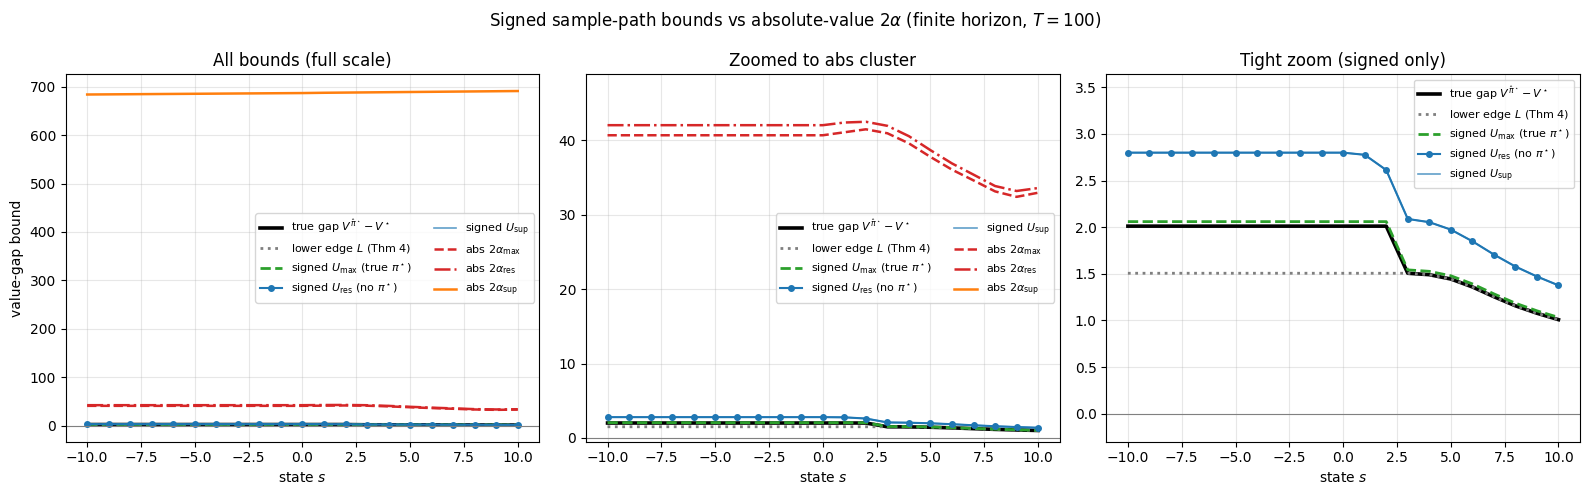

saved ../figures/finite_horizon/all_bounds_comparison.pdf


In [29]:
# =====================================================================
# Comparison plot: ALL bounds (signed variants vs absolute-value 2*alpha)
#   3 panels: full scale | zoomed to abs cluster | tight zoom (signed only)
# =====================================================================
import os
os.makedirs('../figures/finite_horizon', exist_ok=True)

lo, hi = s_max - 10, s_max + 10 + 1
xs = states[lo:hi]

fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(16, 5))

def draw(ax, signed_only=False):
    ax.plot(xs, gap_fh[lo:hi],          'k-',   lw=2.6, label=r'true gap $V^{\hat\pi^\star}-V^\star$')
    ax.plot(xs, L_lower[lo:hi],         'C7:',  lw=2.0, label=r'lower edge $L$ (Thm 4)')
    ax.plot(xs, U_signed_max[lo:hi],    'C2--', lw=2.0, label=r'signed $U_{\max}$ (true $\pi^\star$)')
    ax.plot(xs, U_signed_res[lo:hi],    'C0-o', ms=4,   label=r'signed $U_{\mathrm{res}}$ (no $\pi^\star$)')
    ax.plot(xs, U_signed_sup[lo:hi],    'C0-',  lw=1.2, alpha=0.7, label=r'signed $U_{\sup}$')
    if not signed_only:
        ax.plot(xs, 2*alpha_max_fh[lo:hi],  'C3--', lw=1.8, label=r'abs $2\alpha_{\max}$')
        ax.plot(xs, 2*alpha_res_fh[lo:hi],  'C3-.', lw=1.8, label=r'abs $2\alpha_{\mathrm{res}}$')
        ax.plot(xs, 2*alpha_sup_fh[lo:hi],  'C1-',  lw=1.8, label=r'abs $2\alpha_{\sup}$')
    ax.axhline(0.0, color='gray', lw=0.8)
    ax.set_xlabel('state $s$')
    ax.grid(alpha=0.3)

# Left: full range (so abs 2*alpha_sup is visible)
draw(axL)
axL.set_ylabel('value-gap bound')
axL.set_title('All bounds (full scale)')
axL.legend(fontsize=8, ncol=2)

# Middle: zoomed-in y so the abs 2*alpha_max/res band is readable
draw(axM)
axM.set_ylim(-0.5, float(np.max(2*alpha_res_fh[lo:hi])) * 1.15)
axM.set_title('Zoomed to abs cluster')
axM.legend(fontsize=8, ncol=2)

# Right: tight zoom isolating only the signed bounds + gap + lower edge
draw(axR, signed_only=True)
ytop = max(float(np.max(U_signed_sup[lo:hi])),
           float(np.max(gap_fh[lo:hi]))) * 1.30
axR.set_ylim(-0.3, ytop)
axR.set_title('Tight zoom (signed only)')
axR.legend(fontsize=8)

fig.suptitle('Signed sample-path bounds vs absolute-value $2\\alpha$ (finite horizon, $T=100$)')
fig.tight_layout()
fig.savefig('../figures/finite_horizon/all_bounds_comparison.pdf')
fig.savefig('../figures/finite_horizon/signed_vs_abs_zoomed_in.pdf')
plt.show()
print('saved ../figures/finite_horizon/all_bounds_comparison.pdf')

In [30]:
# =====================================================================
# Summary table over the operating region [-7, 3]
# =====================================================================
op_lo, op_hi = s_max - 7, s_max + 3 + 1

def region_max(arr):
    return float(np.max(arr[op_lo:op_hi]))

rows = [
    ('true gap',                region_max(gap_fh)),
    ('signed U_max',            region_max(U_signed_max)),
    ('signed U_res',            region_max(U_signed_res)),
    ('signed U_sup',            region_max(U_signed_sup)),
    ('abs 2*alpha_max',         region_max(2 * alpha_max_fh)),
    ('abs 2*alpha_res',         region_max(2 * alpha_res_fh)),
    ('abs 2*alpha_sup',         region_max(2 * alpha_sup_fh)),
    ('lower edge L',            region_max(L_lower)),
]

print(f'{"quantity":<22}{"max over [-7,3]":>16}')
print('-' * 38)
for name, val in rows:
    print(f'{name:<22}{val:>16.4f}')

print('\nTightening factor (abs / signed) over [-7,3]:')
print(f'  res variant: {region_max(2*alpha_res_fh) / region_max(U_signed_res):.2f}x')
print(f'  max variant: {region_max(2*alpha_max_fh) / region_max(U_signed_max):.2f}x')

quantity               max over [-7,3]
--------------------------------------
true gap                        2.0112
signed U_max                    2.0597
signed U_res                    2.7990
signed U_sup                    2.7990
abs 2*alpha_max                41.4470
abs 2*alpha_res                42.4589
abs 2*alpha_sup               688.3304
lower edge L                    1.5061

Tightening factor (abs / signed) over [-7,3]:
  res variant: 15.17x
  max variant: 20.12x


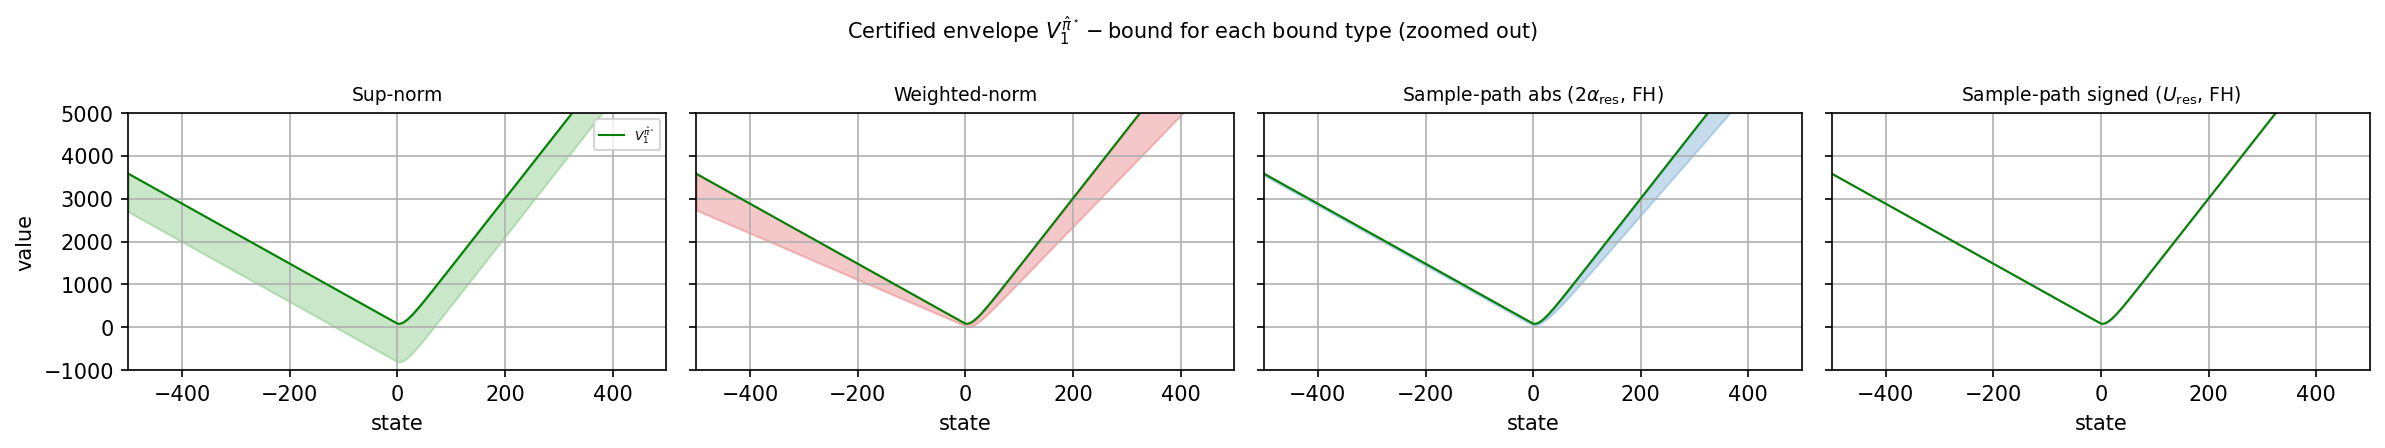

saved ../figures/finite_horizon/4panel_zoomed_out_signed.pdf


In [31]:
# =====================================================================
# Figure-1 equivalent (zoomed out), now INCLUDING the signed sample-path bound.
#   Each panel shows V^{pihat*}_1 (green) and the certified envelope
#   V^{pihat*}_1 - bound, i.e. the guaranteed region for V*. A thinner band
#   means a tighter certificate. The two sample-path panels use the
#   "restricted" variant (no true pi* required).
# =====================================================================
V_pi_hat_fh = V_pi_hat_fh_all[1]

plt.rcParams['pdf.fonttype'] = 42
fig, axes = plt.subplots(1, 4, figsize=(16, 3), dpi=150, sharey=True)

titles = ['Sup-norm', 'Weighted-norm',
          r'Sample-path abs ($2\alpha_{\mathrm{res}}$, FH)',
          r'Sample-path signed ($U_{\mathrm{res}}$, FH)']
bounds_list = [sup_bound_curve, weighted_bound_curve,
               2 * alpha_res_fh, U_signed_res]
colors = ['#2ca02c', '#d62728', '#1f77b4', '#9467bd']

for ax, title, bound, clr in zip(axes, titles, bounds_list, colors):
    ax.plot(states, V_pi_hat_fh, linewidth=1, color='green',
            label=r'$V^{\hat\pi^\star}_1$')
    ax.fill_between(states, V_pi_hat_fh, V_pi_hat_fh - bound,
                    alpha=0.25, color=clr)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('state')
    ax.grid(True)
    ax.set_xlim(-s_max, s_max)
    ax.set_ylim(-1000, 5000)

axes[0].set_ylabel('value')
axes[0].legend(loc='best', fontsize=6)
fig.suptitle('Certified envelope $V^{\\hat\\pi^\\star}_1 - \\mathrm{bound}$ '
             'for each bound type (zoomed out)', fontsize=10)
plt.tight_layout()

os.makedirs('../figures/finite_horizon', exist_ok=True)
plt.savefig('../figures/finite_horizon/4panel_zoomed_out_signed.pdf',
            format='pdf', bbox_inches='tight')
plt.show()
print('saved ../figures/finite_horizon/4panel_zoomed_out_signed.pdf')

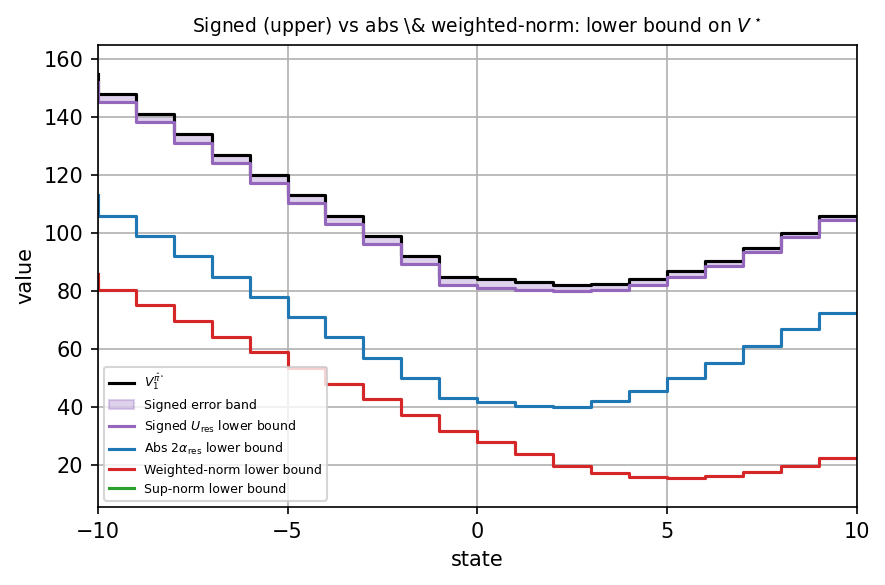

saved ../figures/finite_horizon/signed_vs_abs_weighted_upper_zoomed_in.pdf


In [32]:
# =====================================================================
# Graph 1: signed UPPER bound vs abs-value & weighted-norm counterparts.
#   All three certify a LOWER bound on V*:  V* >= V^{pihat*}_1 - bound.
#   The closer the lower curve is to V^{pihat*}_1 (black), the tighter.
#   Signed uses the "restricted" variant U_res (no true pi* needed).
# =====================================================================
V_pi_hat_fh = V_pi_hat_fh_all[1]
lo, hi = s_max - 10, s_max + 10 + 1
xs = states[lo:hi]
Vp = V_pi_hat_fh[lo:hi]

signed_lower = Vp - U_signed_res[lo:hi]          # signed (sample-path, no pi*)
abs_lower    = Vp - 2 * alpha_res_fh[lo:hi]       # abs value (sample-path)
wn_lower     = Vp - weighted_bound_curve[lo:hi]   # weighted-norm (non sample-path)
sn_lower     = Vp - sup_bound_curve[lo:hi]        # sup-norm (non sample-path)

plt.rcParams['pdf.fonttype'] = 42
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.step(xs, Vp, linewidth=1.5, color='black', label=r'$V^{\hat\pi^\star}_1$')
ax.fill_between(xs, Vp, signed_lower, alpha=0.30, color='#9467bd', step='pre',
                label='Signed error band')
ax.step(xs, signed_lower, linewidth=1.5, color='#9467bd',
        label=r'Signed $U_{\mathrm{res}}$ lower bound')
ax.step(xs, abs_lower, linewidth=1.5, color='#1f77b4',
        label=r'Abs $2\alpha_{\mathrm{res}}$ lower bound')
ax.step(xs, wn_lower, linewidth=1.5, color='#d62728',
        label='Weighted-norm lower bound')
ax.step(xs, sn_lower, linewidth=1.5, color='#2ca02c',
        label='Sup-norm lower bound')

ax.set_xlabel('state')
ax.set_ylabel('value')
ax.set_title(r'Signed (upper) vs abs \& weighted-norm: lower bound on $V^\star$',
             fontsize=9)
ax.set_xlim(-10, 10)
ax.set_xticks(np.arange(-10, 11, 5))
ymin = min(float(np.min(wn_lower)), float(np.min(abs_lower))) - 10
ymax = float(np.max(Vp)) + 10
ax.set_ylim(ymin, ymax)
ax.legend(loc='lower left', fontsize=6)
ax.grid(True)
plt.tight_layout()

plt.savefig('../figures/finite_horizon/signed_vs_abs_weighted_upper_zoomed_in.pdf',
            format='pdf', bbox_inches='tight')
plt.show()
print('saved ../figures/finite_horizon/signed_vs_abs_weighted_upper_zoomed_in.pdf')

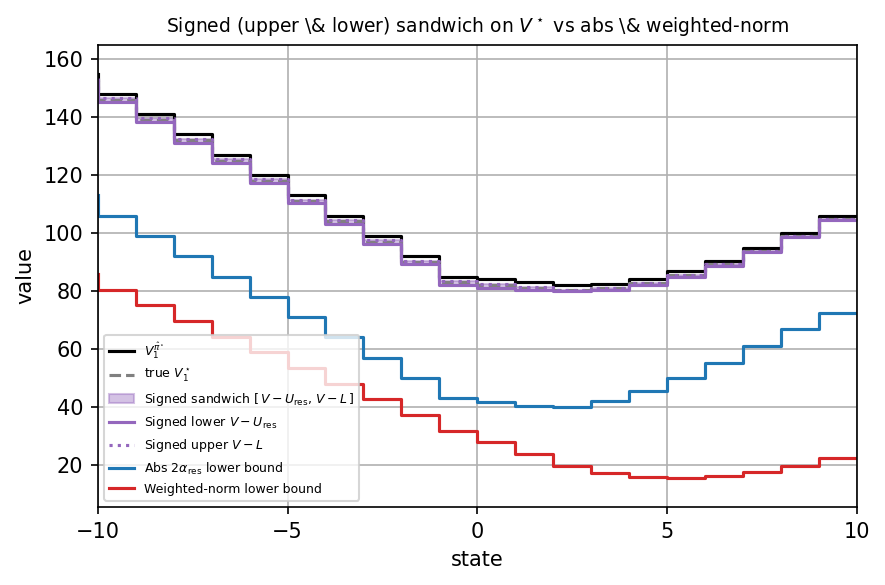

saved ../figures/finite_horizon/signed_sandwich_vs_abs_weighted_zoomed_in.pdf


In [33]:
# =====================================================================
# Graph 2: signed UPPER and LOWER bound -> two-sided sandwich on V*.
#   Upper bound U on the gap  =>  V* >= V^{pihat*}_1 - U   (lower curve)
#   Lower edge L on the gap   =>  V* <= V^{pihat*}_1 - L   (upper curve)
#   so   V^{pihat*}_1 - U  <=  V*  <=  V^{pihat*}_1 - L.
#   The abs-value and weighted-norm bounds give only the one-sided lower
#   curve (their non-trivial upper side collapses to V^{pihat*}_1 itself).
# =====================================================================
V_pi_hat_fh = V_pi_hat_fh_all[1]
V_star_fh   = V_M_all[1]
lo, hi = s_max - 10, s_max + 10 + 1
xs = states[lo:hi]
Vp = V_pi_hat_fh[lo:hi]

signed_lo = Vp - U_signed_res[lo:hi]   # lower bound on V*  (from upper bound U)
signed_hi = Vp - L_lower[lo:hi]        # upper bound on V*  (from lower edge L)
abs_lower = Vp - 2 * alpha_res_fh[lo:hi]
wn_lower  = Vp - weighted_bound_curve[lo:hi]

plt.rcParams['pdf.fonttype'] = 42
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.step(xs, Vp, linewidth=1.5, color='black', label=r'$V^{\hat\pi^\star}_1$')
ax.step(xs, V_star_fh[lo:hi], linewidth=1.5, color='gray', linestyle='--',
        label=r'true $V^\star_1$')

# signed two-sided sandwich
ax.fill_between(xs, signed_hi, signed_lo, alpha=0.40, color='#9467bd', step='pre',
                label=r'Signed sandwich $[\,V-U_{\mathrm{res}},\,V-L\,]$')
ax.step(xs, signed_lo, linewidth=1.5, color='#9467bd',
        label=r'Signed lower $V-U_{\mathrm{res}}$')
ax.step(xs, signed_hi, linewidth=1.5, color='#9467bd', linestyle=':',
        label=r'Signed upper $V-L$')

# one-sided counterparts
ax.step(xs, abs_lower, linewidth=1.5, color='#1f77b4',
        label=r'Abs $2\alpha_{\mathrm{res}}$ lower bound')
ax.step(xs, wn_lower, linewidth=1.5, color='#d62728',
        label='Weighted-norm lower bound')

ax.set_xlabel('state')
ax.set_ylabel('value')
ax.set_title(r'Signed (upper \& lower) sandwich on $V^\star$ vs abs \& weighted-norm',
             fontsize=9)
ax.set_xlim(-10, 10)
ax.set_xticks(np.arange(-10, 11, 5))
ymin = min(float(np.min(wn_lower)), float(np.min(abs_lower))) - 10
ymax = float(np.max(Vp)) + 10
ax.set_ylim(ymin, ymax)
ax.legend(loc='lower left', fontsize=6)
ax.grid(True)
plt.tight_layout()

plt.savefig('../figures/finite_horizon/signed_sandwich_vs_abs_weighted_zoomed_in.pdf',
            format='pdf', bbox_inches='tight')
plt.show()
print('saved ../figures/finite_horizon/signed_sandwich_vs_abs_weighted_zoomed_in.pdf')